# 114_01 — Simulación y preprocesamiento · Escenario TAR (cambio de régimen por umbral sobre el rezago propio)

Paso **1 de 5** del ciclo `Python → MATLAB → Python`:
- 01: **este notebook** genera los datos, ajusta base + FPCA (**sin estandarizar los scores**), escribe los datasets AR
- 02: `psbp_fd_iteracion.m` muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento
- 03, 04, 05: `114_03_convergencia` / `114_04_evaluacion` / `114_05_comparacion`

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de experimento.

> **Corrida 114 — escenario TAR (umbral sobre el rezago propio).** Escenario construido para poner a prueba el gating: cada score activo $\xi_1..\xi_4$ cambia de régimen según **su propio rezago**, con $P(B \mid u_{t-1}) = \Phi((u_{t-1}-c)/h)$ —la misma forma probit del gating del PSBP—; el régimen A es persistente y tranquilo, el B revierte y es volátil. Media condicional en forma de carpa y predictiva heterocedástica: brecha oráculo − AR(2) propio de 0.41 / 0.51 / 0.42 / 0.44 (0.386 agregada en $L^2$; en C-1 era 0.023). Generador y calibración: `pipelines/sim_escenario_TAR.py`.
>
> Pipeline de la 113 sin cambios de arquitectura: rezago propio (`N_LAGS = 2`; la dinámica usa 1 rezago, el 2 es covariable sin información), `M = 1..6` entrenando sólo `M = 6`, sampler corregido (`[FIX 3]`–`[FIX 6]`). Variante **`chungEscG`**: Chung y Dunson §4.2 en escala cruda con **gating más libre** (`taupsij = 10·sd_x²`, sd a priori de ψ en unidades z de 0.32), `btau = 0.5·sd_y²`, `atau = ag = bg = 0.5`, `mupsij = 0`; inclusión lag 1: 0.5/0.5, lag 2: 0.5/5.


## 1. Imports y rutas

In [2]:
import json
import math
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generadores y contrato de artefactos
from model_psbp_fd.pipelines import (
    ConfigEscenarioTAR, generar_escenario_TAR,
    guardar_escenario,
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines
# Rutas del contrato y convención del EXPERIMENT_ID: el gemelo Python de
# config_paths.m. Antes esta sección armaba el dict PATHS a mano.
from model_psbp_fd.utils import (
    get_project_root, experiment_id, normalizar_lista_M,
    rutas_por_M, guardar_en_todos, replicar_figura,
)
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline


### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [3]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Variantes de la 114 (una por defecto). Se corre este notebook UNA VEZ POR VARIANTE.
VARIANTES = {
    # Chung §4.2 en escala cruda con gating mas libre (taupsij_z = 10, sd psi 0.32 en z).
    "chungEscG": {"hiperparametros": "chung_escala_cruda", "N": 30, "taupsij_z": 10.0},
    # Control opcional: el prior de psi del paper (taupsij_z = 100).
    "chungEsc":  {"hiperparametros": "chung_escala_cruda", "N": 30},
}
VARIANTE = "chungEscG"

VAR_CFG      = {"covariables": "propio", **VARIANTES[VARIANTE]}
CRUZADOS     = VAR_CFG["covariables"] == "cruzados"
BASENAME     = f"escenario_114_{VARIANTE}"
ESCENARIO_ID = 1      # escenario TAR (único)
REPLICA_ID   = 1      # réplica Monte Carlo
SEED         = 41232  # semilla base; MATLAB la LEE de hyperparameters.json

# Regla del 95 % en M = 5; M = 4 cubre el bloque activo del generador.
M_FPCA_LIST = (1, 2, 3, 4, 5, 6)

LIMPIAR_DIRECTORIOS = True

# FUnciones
M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
M_ENTRENO       = max(M_FPCA_LIST)   # rezago propio: único M que se entrena (cruzados: todos)
EXPERIMENT_BASE = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID)

print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"VARIANTE        : {VARIANTE}  {VAR_CFG}")
print(f"Escenario {ESCENARIO_ID} · réplica {REPLICA_ID} · seed base {SEED}")
print(f"barrido en M    : {list(M_FPCA_LIST)}   (se entrena solo M={M_ENTRENO})")
for _M in M_FPCA_LIST:
    print(f"   M={_M}  ->  {experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M)}")


PROJECT_ROOT    : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_BASE : escenario_114_chungEscG_1_r01
VARIANTE        : chungEscG  {'covariables': 'propio', 'hiperparametros': 'chung_escala_cruda', 'N': 30, 'taupsij_z': 10.0}
Escenario 1 · réplica 1 · seed base 41232
barrido en M    : [1, 2, 3, 4, 5, 6]   (se entrena solo M=6)
   M=1  ->  escenario_114_chungEscG_1_r01_m01
   M=2  ->  escenario_114_chungEscG_1_r01_m02
   M=3  ->  escenario_114_chungEscG_1_r01_m03
   M=4  ->  escenario_114_chungEscG_1_r01_m04
   M=5  ->  escenario_114_chungEscG_1_r01_m05
   M=6  ->  escenario_114_chungEscG_1_r01_m06


In [4]:
PATHS_POR_M = rutas_por_M(BASENAME, ESCENARIO_ID, REPLICA_ID, M_FPCA_LIST,
                          dominio="simulaciones", project_root=PROJECT_ROOT,
                          limpiar=LIMPIAR_DIRECTORIOS)

for M, p in PATHS_POR_M.items():
    print(f"M={M}  ({experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)})")
    for nombre, ruta in p.items():
        print(f"  {nombre:12s} -> {ruta}")

M=1  (escenario_114_chungEscG_1_r01_m01)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_114_chungEscG_1_r01_m01
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_114_chungEscG_1_r01_m01
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_114_chungEscG_1_r01_m01
  out_report   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_114_chungEscG_1_r01_m01
  out_artefact -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_114_chungEscG_1_r01_m01
M=2  (escenario_114_chungEscG_1_r01_m02)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_114_chungEscG_1_r01_m02
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\s

### 2.1 `[CONFIG]` Parámetros del generador

`sim_escenario_TAR`: $X_t(\tau)=\mu(\tau)+\sum_{j=1}^{10}\xi_{tj}\varphi_j(\tau)$ con la base de Fourier y $\mu(\tau)=\sin(2\pi\tau)$ de la sección C. Cada score activo $j = 1..4$ sigue, en una coordenada cruda $u_j$, un AR(1) con dos regímenes asignados por **su propio rezago**:

$$P(R_{tj}=B\mid u_{j,t-1})=\Phi\!\left(\frac{u_{j,t-1}-c_j}{h_j}\right),\qquad u_{tj}=\mu_{R}+\phi_{R}\,u_{j,t-1}+s_{R}\,e_{tj}.$$

A es persistente y tranquilo, B revierte y es volátil; las componentes son independientes entre sí. $\xi_5..\xi_{10}$ son AR(1) propios con coeficiente 0.3. Parámetros y calibración: docstring de `pipelines/sim_escenario_TAR.py`. Regímenes, oráculo y soporte viven en `salida.internos`: **no** se entregan a la estimación.

In [5]:
# ── Parámetros fijos del estudio (comunes a los escenarios) ─────────────────
L_GRILLA   = 75     # puntos de la grilla
T_CURVAS   = 1000   # curvas retenidas tras el calentamiento
PROP_TRAIN = 0.70   # proporción del bloque de entrenamiento
SIGMA_OBS  = 0.25   # desviación del ruido de medición

SIM_CFG = ConfigEscenarioTAR(
    L         = L_GRILLA,
    T         = T_CURVAS,
    burn_in   = 300,          # como la sección B
    sigma_obs = SIGMA_OBS,
    R         = 1,            # una réplica por corrida; el barrido usa REPLICA_ID
    seed      = SEED,
    # J, n_rezagos, lambda_1, rho: valores del módulo (sim_escenario_TAR.py)
    prop_train_referencia = PROP_TRAIN,
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<24}: {v}")


  L                       : 75
  T                       : 1000
  burn_in                 : 300
  sigma_obs               : 0.25
  R                       : 1
  seed                    : 41232
  media_fn                : media_seno
  jitter                  : 1e-10
  J                       : 10
  n_rezagos               : 2
  lambda_1                : 0.5
  rho                     : 0.55
  prop_train_referencia   : 0.7


### 2.2 Generación

In [6]:
salida = generar_escenario_TAR(SIM_CFG)

REPLICA_IDX = REPLICA_ID - 1
X_raw  = salida.observaciones[REPLICA_IDX]   # (T, G) OBSERVADA — alimenta la estimación
X_true = salida.curvas[REPLICA_IDX]          # (T, G) VERDADERA — sólo referencia
grilla = salida.grilla
T, G   = X_raw.shape

print(f"Observadas {X_raw.shape} · verdaderas {X_true.shape} · grilla {grilla.shape}")
print(f"Ruido de medición efectivo: sd(X_raw - X_true) = {(X_raw - X_true).std():.4f}"
      f"   (nominal {SIGMA_OBS})")
print("\nControl de calidad del generador:")
for k, v in salida.diagnostico.items():
    print(f"  {k:32s} = {v}")


Observadas (1000, 75) · verdaderas (1000, 75) · grilla (75,)
Ruido de medición efectivo: sd(X_raw - X_true) = 0.2500   (nominal 0.25)

Control de calidad del generador:
  n_replicas                       = 1
  n_curvas                         = 1000
  n_puntos_grilla                  = 75
  todo_finito                      = True
  media_empirica_global            = -0.0008933614892921632
  media_ee_montecarlo              = nan
  var_puntual_media                = 1.0872636494156545
  var_puntual_min                  = 0.787730910756315
  var_puntual_max                  = 1.2735603021383204
  acf1_media                       = 0.24758359345180664
  acf1_ee_montecarlo               = nan
  razon_senal_ruido                = 17.39621839065047
  n_rezagos                        = 2
  ocupacion_regimen_B              = [0.416, 0.461, 0.414, 0.524]
  racha_media                      = [6.578947368421053, 4.424778761061948, 5.02959595959596, 4.23728813559322]
  r2_oraculo_por_componente   

In [7]:
for _M, _p in PATHS_POR_M.items():
    simulation_config = {
        "sim_params":    salida.config.to_dict(),
        "diagnostico":   salida.diagnostico,
        "replica_idx":   REPLICA_IDX,
        "experiment_id": experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M),
        "escenario_id":  int(ESCENARIO_ID),
        "replica_id":    int(REPLICA_ID),
        "m_fpca":        int(_M),
        "m_fpca_list":   [int(m) for m in M_FPCA_LIST],
        "seed":          SEED,
        "T": int(T), "G": int(G),
    }
    with open(_p["raw"] / "simulation_config.json", "w", encoding="utf-8") as f:
        json.dump(simulation_config, f, indent=2, ensure_ascii=False)

    _npz = guardar_escenario(salida, str(_p["raw"] / f"escenario_{ESCENARIO_ID}"),
                             incluir_curvas=True, incluir_internos=True)
    print(f"[raw · M={_M}] simulation_config.json  ·  {_npz}")

[raw · M=1] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_114_chungEscG_1_r01_m01\escenario_1.npz
[raw · M=2] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_114_chungEscG_1_r01_m02\escenario_1.npz
[raw · M=3] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_114_chungEscG_1_r01_m03\escenario_1.npz
[raw · M=4] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_114_chungEscG_1_r01_m04\escenario_1.npz
[raw · M=5] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_114_chungEscG_1_r01_m05\escenario_1.npz
[raw · M=6] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_114_chungEscG_

### 2.3 Visualización de los datos

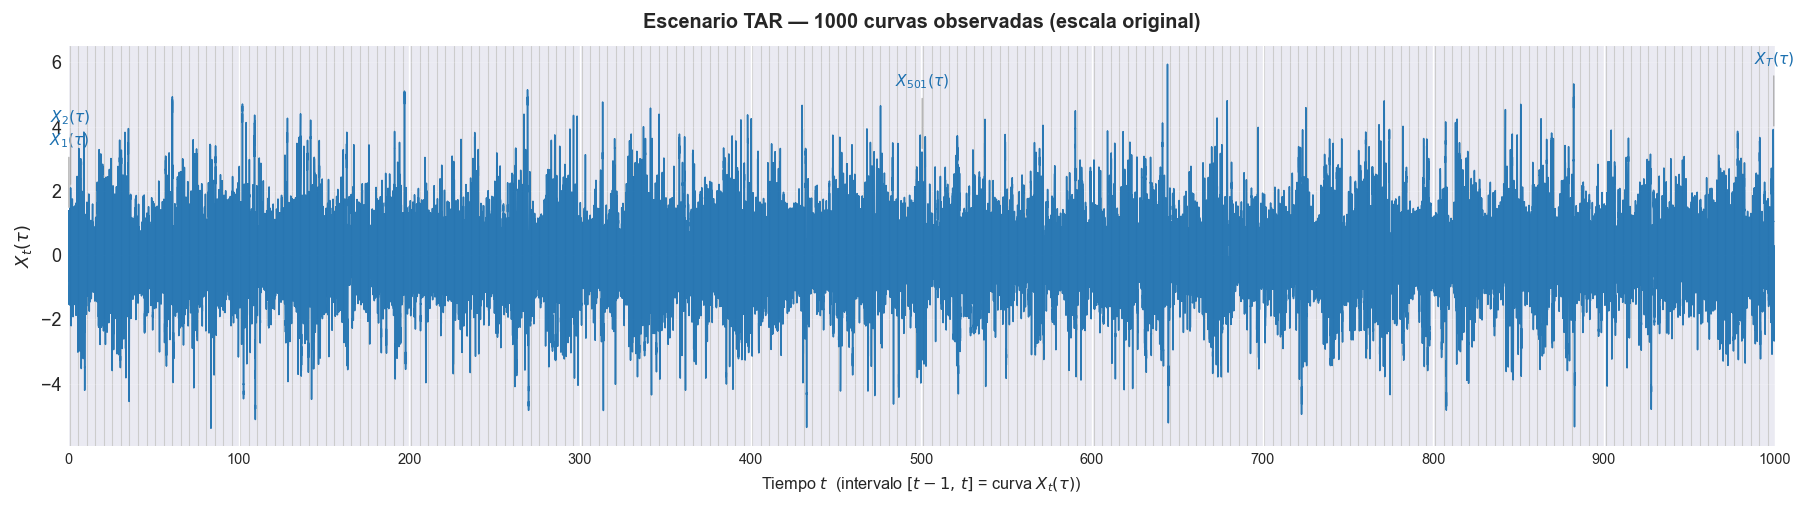

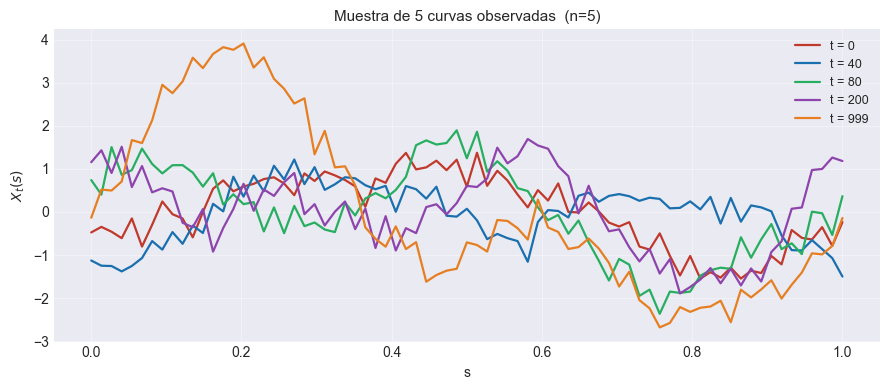

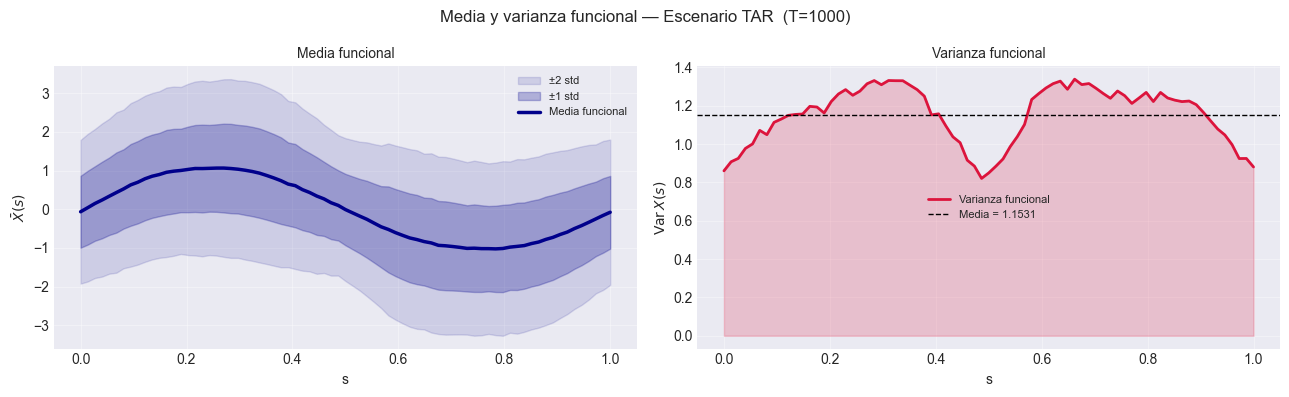

In [8]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"Escenario TAR — {T} curvas observadas (escala original)")
replicar_figura("01_fts_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, 40, 80, 200, T - 1],
    title="Muestra de 5 curvas observadas")
replicar_figura("02_muestra_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title="Media y varianza funcional — Escenario TAR")
replicar_figura("03_media_varianza_raw.png", PATHS_POR_M)
plt.show()

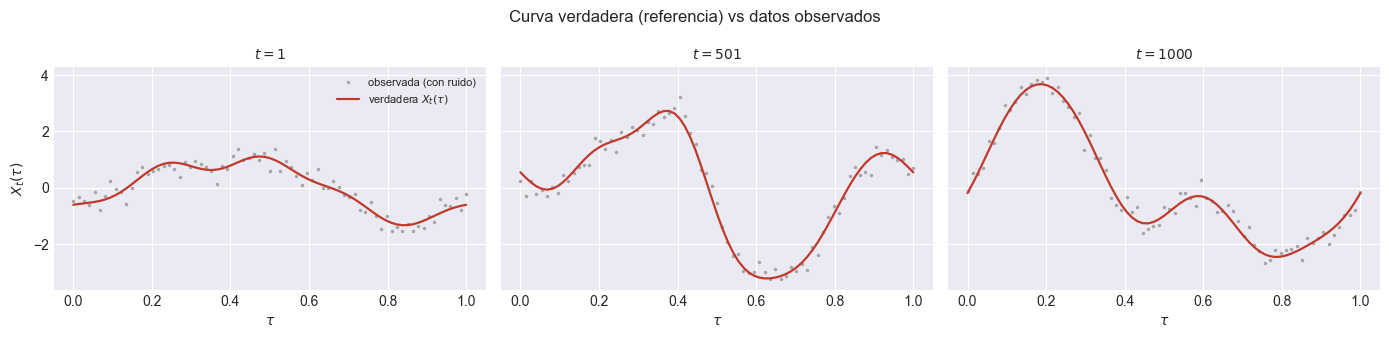

In [9]:
# Curva observada vs verdadera: dimensiona el ruido que el modelo NO debe predecir
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for ax, i in zip(axes, [0, T // 2, T - 1]):
    ax.plot(grilla, X_raw[i], ".", color="0.65", ms=3, label="observada (con ruido)")
    ax.plot(grilla, X_true[i], color="#c0392b", lw=1.6, label="verdadera $X_t(\\tau)$")
    ax.set_title(rf"$t={i+1}$", fontsize=10); ax.set_xlabel(r"$\tau$")
axes[0].set_ylabel(r"$X_t(\tau)$"); axes[0].legend(fontsize=8)
fig.suptitle("Curva verdadera (referencia) vs datos observados",
             fontsize=12)
fig.tight_layout()
replicar_figura("04_curva_vs_datos.png", PATHS_POR_M, fig=fig)
plt.show()

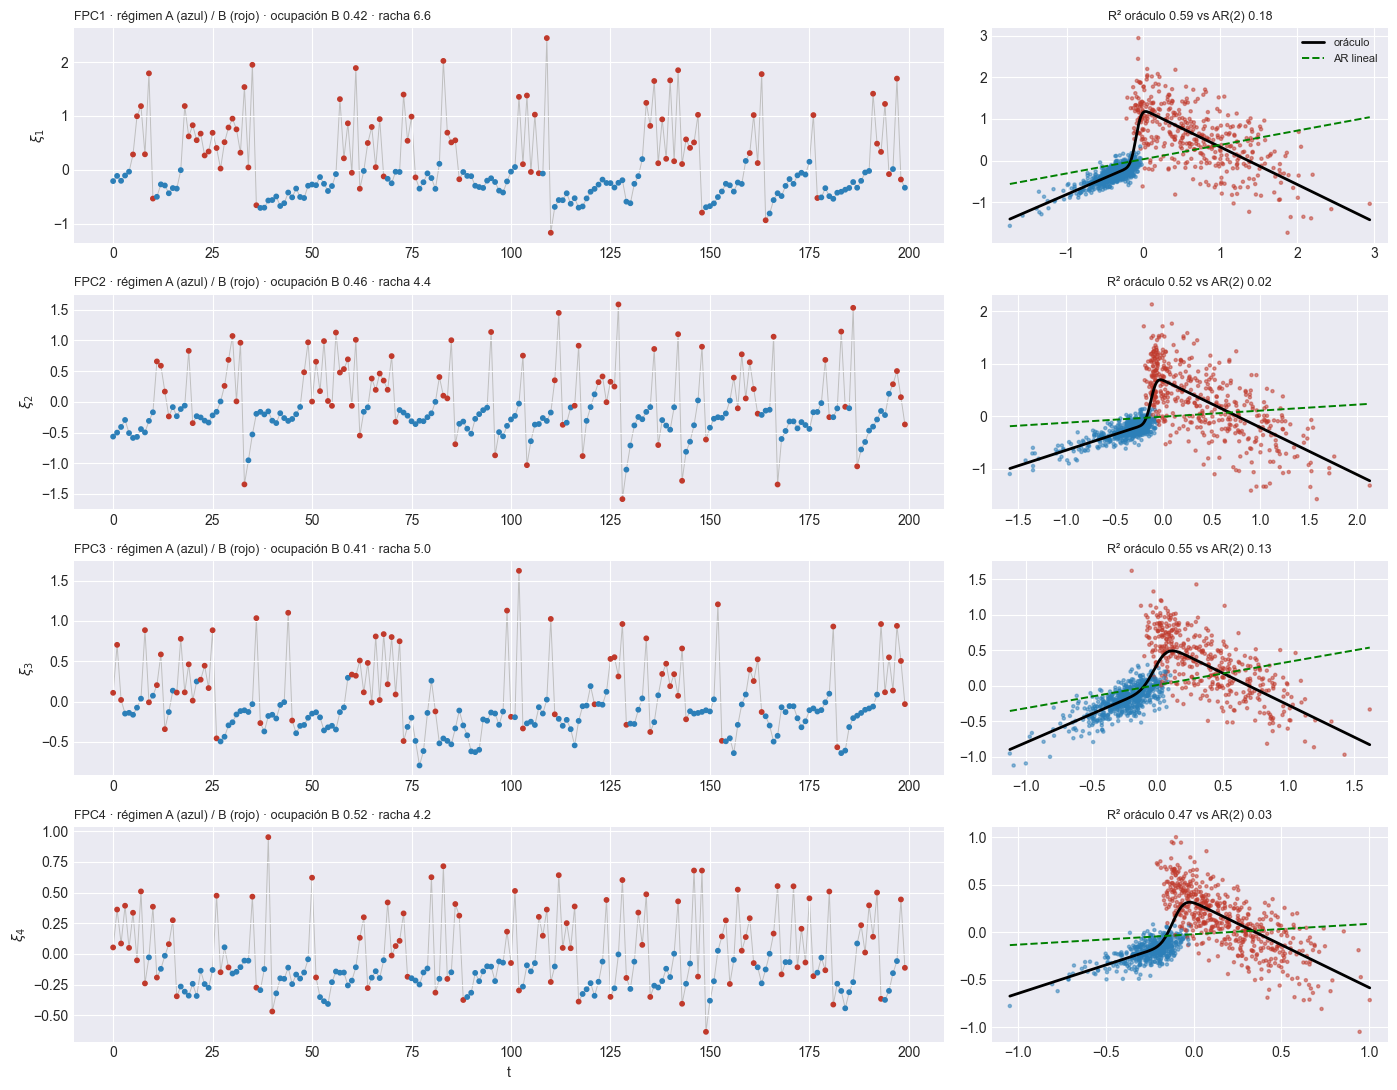

ocupación del régimen B      : [0.416 0.461 0.414 0.524]
racha media                  : [6.58 4.42 5.03 4.24]
R^2 L2 oráculo / lineal      : 0.5130 / 0.1272
R^2 oráculo    xi_1..5       : [0.589 0.525 0.553 0.471 0.091]
R^2 AR propio  xi_1..5       : [0.176 0.02  0.131 0.031 0.094]
var. entre regímenes / total : [0.113 0.101 0.127 0.179]
heterocedasticidad (q4/q1)   : [18.27 17.16  5.16  6.58]
|cos| ejes (scores verd.)    : [0.998 0.994 0.989 0.995 0.999 0.999]


In [10]:
# Regimen sorteado y scores verdaderos (control de calidad, no se entregan).
from scipy.stats import norm
from model_psbp_fd.pipelines.sim_escenario_TAR import PARAMETROS_TAR, MOMENTOS_TAR

REG     = salida.internos["regimen"][REPLICA_IDX]
XI_true = salida.internos["scores"][REPLICA_IDX]
_sc     = salida.internos["escala_scores"]
_d      = salida.diagnostico
_n      = 200

fig, axes = plt.subplots(4, 2, figsize=(14, 11), gridspec_kw={"width_ratios": [2.2, 1]})
for j in range(4):
    a, b = axes[j]
    a.plot(np.arange(_n), XI_true[:_n, j], color="0.75", lw=0.7, zorder=0)
    a.scatter(np.arange(_n), XI_true[:_n, j], s=10,
              c=np.where(REG[:_n, j] == 1, "#c0392b", "#2c7fb8"))
    a.set_ylabel(rf"$\xi_{j+1}$")
    a.set_title(f"FPC{j+1} · régimen A (azul) / B (rojo) · ocupación B "
                f"{_d['ocupacion_regimen_B'][j]:.2f} · racha {_d['racha_media'][j]:.1f}",
                fontsize=9, loc="left")
    x, y = XI_true[:-1, j], XI_true[1:, j]
    b.scatter(x, y, s=5, alpha=0.5, c=np.where(REG[1:, j] == 1, "#c0392b", "#2c7fb8"))
    g = np.linspace(x.min(), x.max(), 300)
    muA, phA, sA, muB, phB, sB, c, h = PARAMETROS_TAR[j]
    m_, d_ = MOMENTOS_TAR[j]
    u = g / _sc[j] * d_ + m_
    p = norm.cdf((u - c) / h)
    b.plot(g, ((1 - p) * (muA + phA * u) + p * (muB + phB * u) - m_) / d_ * _sc[j],
           "k", lw=2, label="oráculo")
    b.plot(g, np.polyval(np.polyfit(x, y, 1), g), "g--", lw=1.4, label="AR lineal")
    b.set_title(f"R² oráculo {_d['r2_oraculo_por_componente'][j]:.2f} vs AR(2) "
                f"{_d['r2_ar_propio_por_componente'][j]:.2f}", fontsize=9)
    if j == 0:
        b.legend(fontsize=8)
axes[-1, 0].set_xlabel("t")
fig.tight_layout()
replicar_figura("04b_mecanismo_scores.png", PATHS_POR_M, fig=fig)
plt.show()

print(f"ocupación del régimen B      : {np.round(_d['ocupacion_regimen_B'], 3)}")
print(f"racha media                  : {np.round(_d['racha_media'], 2)}")
print(f"R^2 L2 oráculo / lineal      : {_d['r2_oraculo']:.4f} / {_d['r2_lineal']:.4f}")
print(f"R^2 oráculo    xi_1..5       : {np.round(_d['r2_oraculo_por_componente'], 3)}")
print(f"R^2 AR propio  xi_1..5       : {np.round(_d['r2_ar_propio_por_componente'], 3)}")
print(f"var. entre regímenes / total : {np.round(_d['fraccion_varianza_entre_regimenes'], 3)}")
print(f"heterocedasticidad (q4/q1)   : {np.round(_d['heterocedasticidad_q4_q1'], 2)}")
print(f"|cos| ejes (scores verd.)    : {np.round(_d['cos_ejes_scores'][:6], 3)}")

### 2.4 Persistencia de curvas

Se guardan las dos matrices con nombres distintos (`X_curves.npy` y
`X_curves_true.npy`) para que no puedan confundirse aguas abajo.

In [11]:
_p = guardar_en_todos(guardar_curvas, PATHS_POR_M, X_raw, grilla, X_true=X_true)
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} -> {ruta.name}"
          f"   (replicado en {len(PATHS_POR_M)} directorios)")

[functional] curvas       -> X_curves.npy   (replicado en 6 directorios)
[functional] grilla       -> domain_grid.npy   (replicado en 6 directorios)
[functional] curvas_true  -> X_curves_true.npy   (replicado en 6 directorios)


### 2.5 Partición temporal

Todo objeto **estimado a partir de los datos** —selección GCV de la base, FPCA,
estandarizador, que aquí queda en identidad— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

In [12]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 700]      → (700, 75)
prueba        : t ∈ [701, 1000]  → (300, 75)
proporción    : 70.0% / 30.0%


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2.

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,6.0727%,0.974946,2.335316,1.156761
1,3,2,31.8001%,0.820875,2.327689,0.863409
2,4,2,70.3995%,0.561277,1.659106,0.385372
3,5,2,76.6583%,0.496350,1.434487,0.312632
4,6,2,86.1033%,0.392140,0.799634,0.191562
5,7,2,88.7858%,0.353286,0.673651,0.159165
6,8,2,91.5706%,0.309221,0.574155,0.123238
7,9,2,92.7775%,0.287307,0.488472,0.108817
8,10,2,93.9540%,0.263937,0.417027,0.093915
9,11,2,94.4569%,0.253028,0.357032,0.088815



GCV mínimo → n_basis=14, order=4  (var retenida 95.5343%)


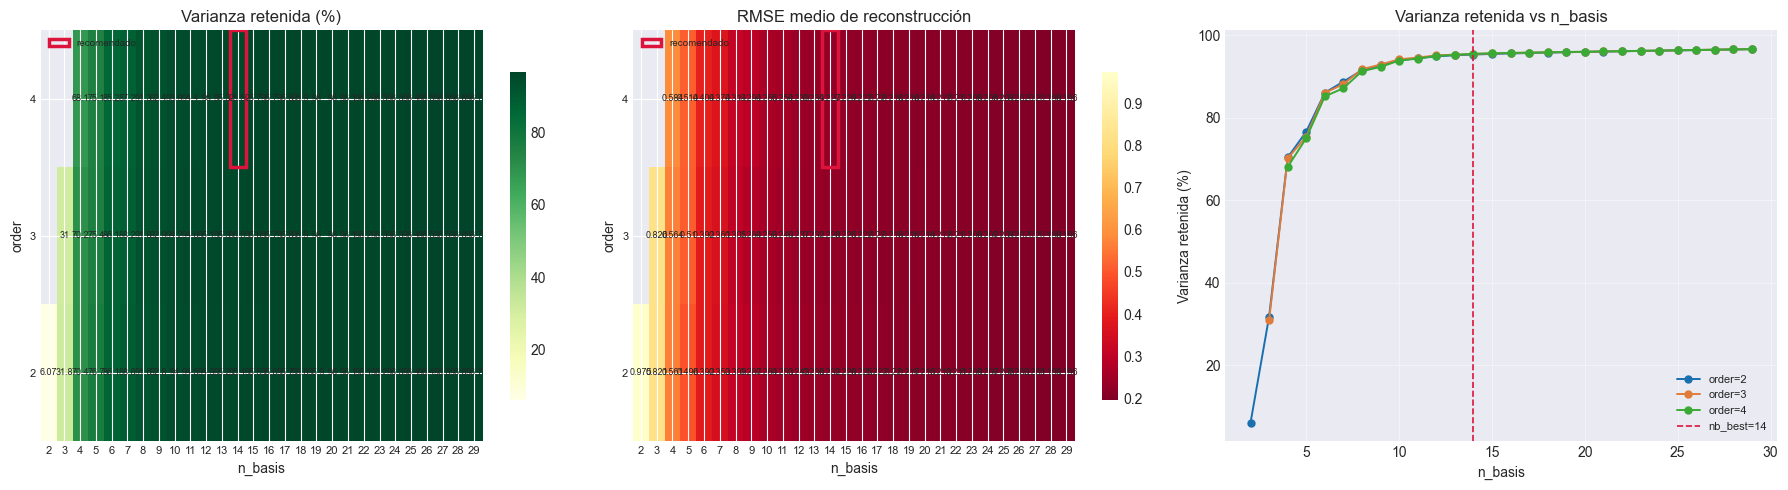

In [13]:
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # acotado por T0
ORDER_RANGE   = range(2, 5)

registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train, grilla)     # sólo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")

plot_seleccion_basis(sel_df, nb_best, ord_best)
replicar_figura("05_seleccion_basis.png", PATHS_POR_M)
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste

`center=False` es imprescindible: con `center=True` la reconstrucción es un
mapa **afín**, y la función media contaminaría la base recuperada por
`base_en_grilla`, la matriz de Gram y las autofunciones.

Base elegida : n_basis=14, order=4
Sugerido GCV : n_basis=14, order=4   (coinciden)
THETA (1000, 14)  (train=700, test=300)
MISE(suavizada, observada) = 0.0519   ·   MISE(suavizada, verdadera) = 0.0127


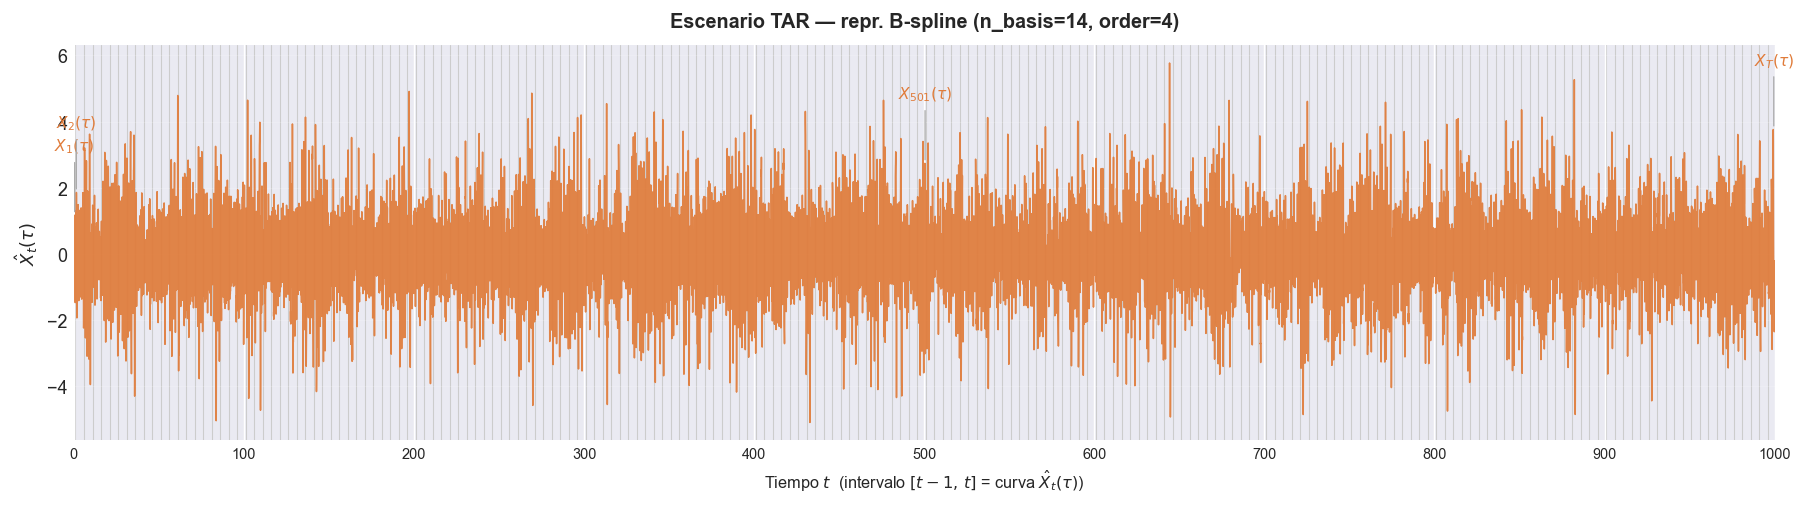

[functional] functional_representation.pkl + theta.csv + fr_config.json   (replicado en 6 directorios)


In [14]:
NB_ELEGIDO  = nb_best     # ← decisión del analista
ORD_ELEGIDO = ord_best

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
X_SUAV      = fr.reconstruct(THETA)           # objetivo de evaluacion (docs 03_05_00)
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")
print(f"MISE(suavizada, observada) = {float((((X_SUAV - X)**2).mean(1)).mean()):.4f}"
      f"   ·   MISE(suavizada, verdadera) = {float((((X_SUAV - X_true)**2).mean(1)).mean()):.4f}")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"Escenario TAR — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})")
replicar_figura("06_fts_funcional_bspline.png", PATHS_POR_M)
plt.show()

guardar_en_todos(guardar_representacion, PATHS_POR_M, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print(f"[functional] functional_representation.pkl + theta.csv + fr_config.json"
      f"   (replicado en {len(PATHS_POR_M)} directorios)")

### 3.3 FPCA generalizado en $L^2$ y diagnóstico



In [15]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

_ver = fpca.verificar(THETA_train, fr=fr)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

# cond(W) amplifica el ruido de las direcciones de menor autovalor, que son las
# que después se truncan. Se registra para comparar escenarios con distinto K.
cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 14
  K                                  = 14
  n_ajuste                           = 700
  cond_W                             = 2.465e+01
  err_ortonormalidad_L2              = 3.553e-15
  err_ortonormalidad_gram            = 3.775e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 8.882e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 2.152e-16
  err_media_scores_rel               = 7.310e-15
  err_var_scores_vs_lambda           = 1.110e-15
  err_var_scores_vs_lambda_rel       = 5.034e-14
  err_correlacion_lag0               = 3.356e-14
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok    

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,4.6976e-01,41.9511%,41.9511%,+0.301
1,2,3.0329e-01,27.0842%,69.0353%,+0.117
2,3,1.6548e-01,14.7779%,83.8132%,+0.321
3,4,7.9044e-02,7.0588%,90.8720%,+0.114
4,5,4.3984e-02,3.9279%,94.7999%,+0.334
5,6,2.4866e-02,2.2206%,97.0205%,+0.273
6,7,1.4312e-02,1.2781%,98.2986%,+0.250
7,8,8.5122e-03,0.7602%,99.0587%,+0.309
8,9,4.7686e-03,0.4258%,99.4846%,+0.183
9,10,2.9909e-03,0.2671%,99.7517%,+0.214



K disponibles: 14   ·   sugerencia (var ≥ 95%): M = 6
  M=1: var. acum = 41.9511%  ·  sensibilidad
  M=2: var. acum = 69.0353%  ·  sensibilidad
  M=3: var. acum = 83.8132%  ·  sensibilidad
  M=4: var. acum = 90.8720%  ·  sensibilidad
  M=5: var. acum = 94.7999%  ·  sensibilidad
  M=6: var. acum = 97.0205%  ·  regla del 95 %


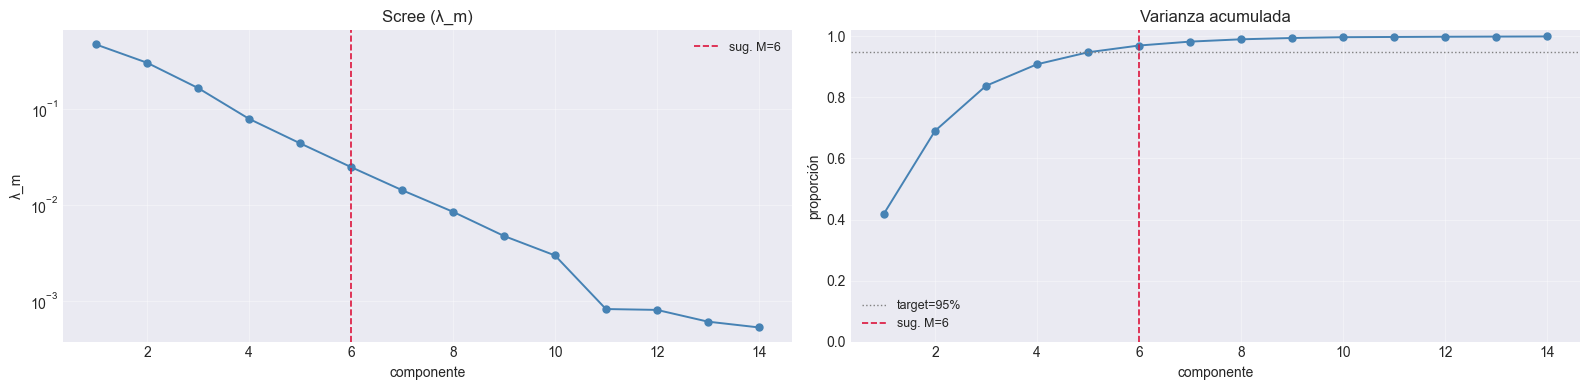

In [16]:
# Varianza ≠ dinámica: una FPC de varianza baja puede tener AR fuerte y ser útil
# para pronóstico, y una de varianza alta puede ser ruido temporal.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum, "ar1_propio": ar1,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))

print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")

# K lo fija el GCV y ACOTA el barrido
assert max(M_FPCA_LIST) <= K, (
    f"M_FPCA_LIST={list(M_FPCA_LIST)} excede el K disponible: la base elegida "
    f"(n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}) da K = {K} componentes. "
    f"Reduzca el barrido o elija una base con más funciones en §3.2.")

_frontera = max(3, int(np.ceil(0.75 * K)))
for _M in M_FPCA_LIST:
    _marca = "regla del 95 %" if _M == M_SUGERIDO else "sensibilidad"
    _aviso = ("   <- cerca del techo K: componente en buena medida artefacto "
              "de una base corta" if _M >= _frontera else "")
    print(f"  M={_M}: var. acum = {fpca.var_cum[_M-1]:.4%}  ·  {_marca}{_aviso}")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET)
replicar_figura("07_fpca_scree.png", PATHS_POR_M)
plt.show()

### 3.4 Series de los componentes de la FPCA
- Se ven todos. 

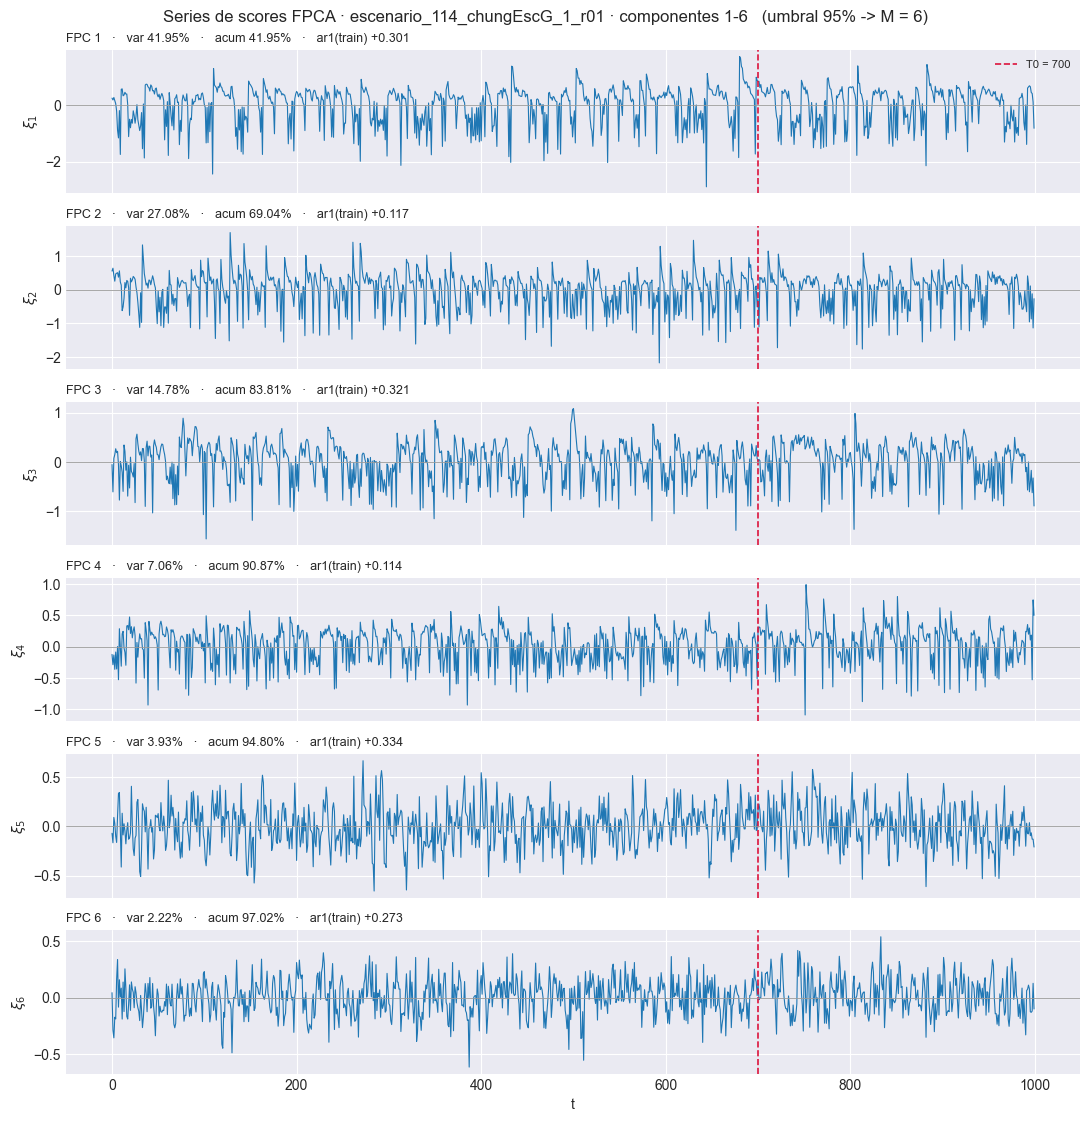

componentes graficadas : 1-6  de K = 14
var. acumulada hasta 6 : 97.0205%


In [17]:
# [CONFIG] §3.4 — hasta que componente se grafica. Por defecto, la que fija el
# umbral VAR_TARGET de la celda anterior; subirlo mira mas alla de la regla.
N_SERIES_SCORES = M_SUGERIDO

assert 1 <= N_SERIES_SCORES <= K, f"N_SERIES_SCORES={N_SERIES_SCORES} fuera de [1, {K}]."

# B_full y no B: no depende de set_M. Serie completa, no solo train.
XI = (THETA - fpca.mu_theta) @ (fpca.W @ fpca.B_full)      # (T, K)

fig, axes = plt.subplots(N_SERIES_SCORES, 1, sharex=True,
                         figsize=(11, 1.9 * N_SERIES_SCORES))
axes = np.atleast_1d(axes)
for k, ax in enumerate(axes):
    ax.plot(np.arange(T), XI[:, k], lw=0.8, color="C0")
    ax.axvline(T0, color="crimson", ls="--", lw=1.2)
    ax.axhline(0, color="0.6", lw=0.6)
    ax.set_ylabel(rf"$\xi_{{{k+1}}}$")
    ax.set_title(f"FPC {k+1}   ·   var {fpca.var_ratio[k]:.2%}   ·   "
                 f"acum {fpca.var_cum[k]:.2%}   ·   ar1(train) {ar1[k]:+.3f}",
                 fontsize=9, loc="left")
axes[-1].set_xlabel("t")
axes[0].plot([], [], color="crimson", ls="--", lw=1.2, label=f"T0 = {T0}")
axes[0].legend(loc="upper right", fontsize=8)

fig.suptitle(f"Series de scores FPCA · {EXPERIMENT_BASE} · componentes 1-"
             f"{N_SERIES_SCORES}   (umbral {VAR_TARGET:.0%} -> M = {M_SUGERIDO})")
fig.tight_layout()
replicar_figura("07b_fpca_scores_series.png", PATHS_POR_M)
plt.show()

print(f"componentes graficadas : 1-{N_SERIES_SCORES}  de K = {K}"
      + ("" if N_SERIES_SCORES == M_SUGERIDO
         else f"   <- DIFIERE del umbral (M_SUGERIDO = {M_SUGERIDO})"))
print(f"var. acumulada hasta {N_SERIES_SCORES} : {fpca.var_cum[N_SERIES_SCORES-1]:.4%}")


### 3.5 Componentes estandarizados — sólo contraste

Los scores **no** se estandarizan: a MATLAB van los de §3.4, en su escala propia. Esta sección muestra lo que se descartó, no lo que se entrega.

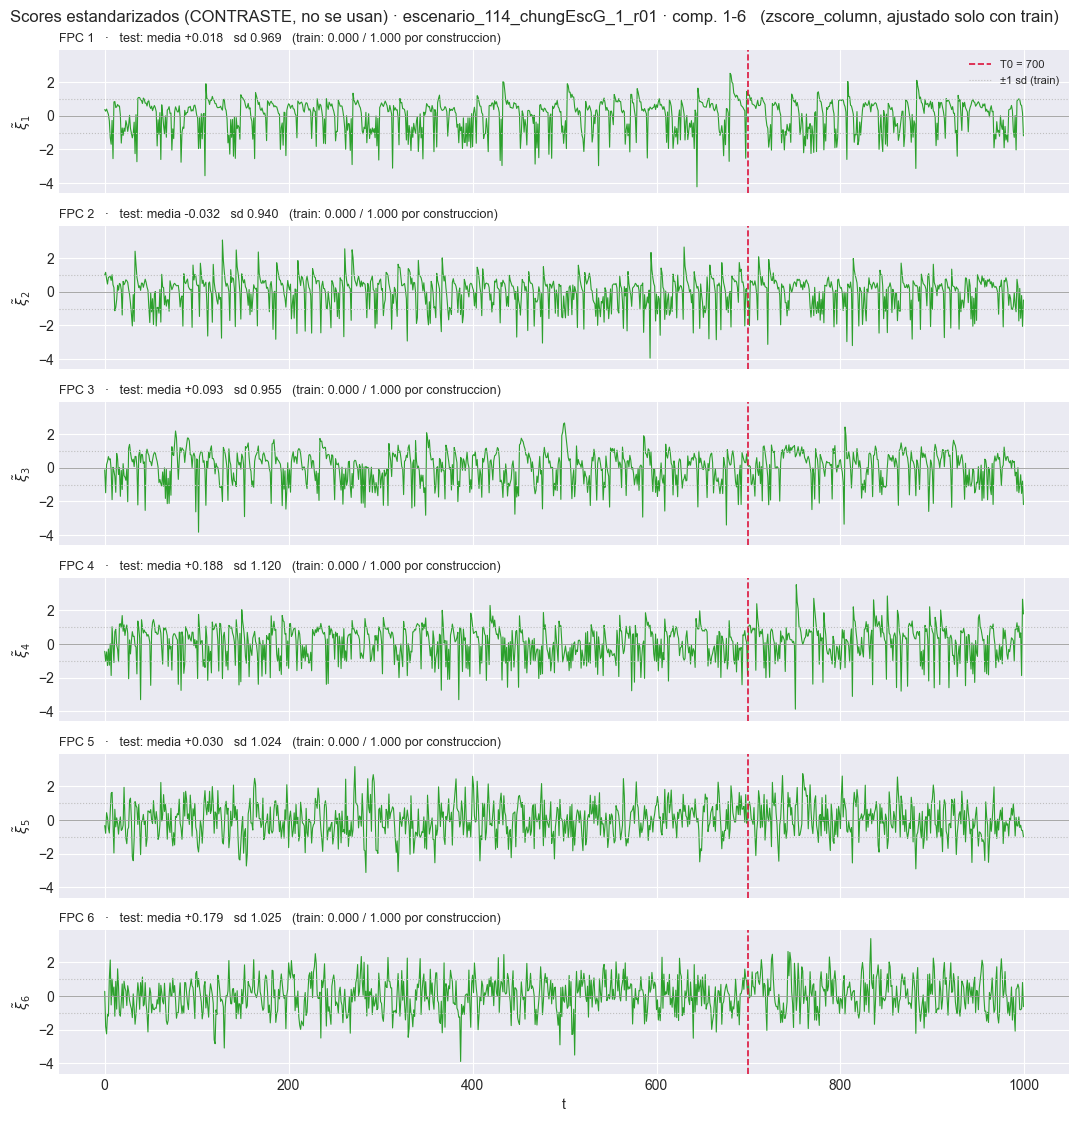

escala original  sd(train) : [0.6849 0.5503 0.4065 0.2809 0.2096 0.1576]
estandarizado    sd(test)  : [0.9687 0.9396 0.9545 1.1199 1.0242 1.0252]    <- lejos de 1 = el bloque de prueba no comparte escala con train


In [18]:
# §3.5 — mismo grafico que §3.4 pero estandarizando. CONTRASTE: NO es lo que
# se entrega. El pipeline usa los scores crudos; esto es la alternativa
# descartada, que se mira para saber cuanto cambia la escala.
_std = DataStandardizer(method="zscore_column", ddof=0)
_std.fit(XI[idx_train, :N_SERIES_SCORES], etiqueta=f"train[1:{T0}]")
XI_STD = _std.transform(XI[:, :N_SERIES_SCORES])            # (T, N_SERIES_SCORES)

fig, axes = plt.subplots(N_SERIES_SCORES, 1, sharex=True, sharey=True,
                         figsize=(11, 1.9 * N_SERIES_SCORES))
axes = np.atleast_1d(axes)
for k, ax in enumerate(axes):
    ax.plot(np.arange(T), XI_STD[:, k], lw=0.8, color="C2")
    ax.axvline(T0, color="crimson", ls="--", lw=1.2)
    ax.axhline(0, color="0.6", lw=0.6)
    for _s in (-1, 1):
        ax.axhline(_s, color="0.75", ls=":", lw=0.8)
    ax.set_ylabel(rf"$\tilde\xi_{{{k+1}}}$")
    ax.set_title(f"FPC {k+1}   ·   test: media {XI_STD[idx_test, k].mean():+.3f}   "
                 f"sd {XI_STD[idx_test, k].std():.3f}   "
                 f"(train: 0.000 / 1.000 por construccion)",
                 fontsize=9, loc="left")
axes[-1].set_xlabel("t")
axes[0].plot([], [], color="crimson", ls="--", lw=1.2, label=f"T0 = {T0}")
axes[0].plot([], [], color="0.75", ls=":", lw=0.8, label="±1 sd (train)")
axes[0].legend(loc="upper right", fontsize=8)

fig.suptitle(f"Scores estandarizados (CONTRASTE, no se usan) · {EXPERIMENT_BASE} · comp. 1-"
             f"{N_SERIES_SCORES}   (zscore_column, ajustado solo con train)")
fig.tight_layout()
plt.show()

print(f"escala original  sd(train) : "
      f"{np.array2string(XI[idx_train, :N_SERIES_SCORES].std(0), precision=4)}")
print(f"estandarizado    sd(test)  : "
      f"{np.array2string(XI_STD[idx_test].std(0), precision=4)}"
      "    <- lejos de 1 = el bloque de prueba no comparte escala con train")


## 4. El bucle sobre `M_FPCA_LIST`

Se realiza:
- §4.1:`set_M(M)` y scores; contraste con la regla del 95 % 
- §4.2: estandarizador en **identidad** (los scores van crudos) y artefactos FPCA 
- §4.3: diagnóstico de rezagos sobre el bloque de entrenamiento
- §4.4: orden AR y construcción de los datasets
- §4.5: hiperparámetros y `mcmc_config` — el contrato con MATLAB
- §4.6: `eval_config`, líneas base y `verificar_contrato` 


In [19]:
# E[tau] se declara como razon_Etau_lambda (= E[tau]*lambda_k, adimensional)
# o como e_tau_objetivo (literal, en 1/var(y)).
CLAVES_ETAU = ("razon_Etau_lambda", "e_tau_objetivo")


def clave_etau(escalera: dict) -> str:
    """La clave de E[tau] en uso, verificando que la escalera sea homogenea."""
    presentes = {c for pel in escalera.values() for c in CLAVES_ETAU if c in pel}
    if not presentes:
        raise KeyError(
            f"Ningun peldano de HP_ESCALERA declara E[tau]. Agrega una de "
            f"{CLAVES_ETAU} a cada uno.")
    if len(presentes) > 1:
        raise KeyError(
            f"HP_ESCALERA mezcla {sorted(presentes)}: los peldanos tienen que "
            "usar la MISMA convencion o los E[tau] no son comparables entre "
            "componentes.")
    clave = presentes.pop()
    faltan = [k for k, pel in escalera.items() if clave not in pel]
    if faltan:
        raise KeyError(f"Peldanos de HP_ESCALERA sin {clave!r}: {sorted(faltan)}.")
    return clave


def e_tau_del_peldano(esc: dict, var_y_k: float) -> float:
    """E[tau] del peldano, cualquiera sea la convencion con que se declaro."""
    if "razon_Etau_lambda" in esc:
        return float(esc["razon_Etau_lambda"]) / max(var_y_k, 1e-12)
    return float(esc["e_tau_objetivo"])


def procesar_punto(M: int) -> dict:
    """Produce TODOS los artefactos del punto M del barrido y verifica su contrato.

    Recibe por clausura los objetos comunes de §2-§3.3 —`fpca` ya ajustado,
    `THETA`, `idx_train`/`idx_test`, `grilla`, `X_true`— y no los recalcula:
    ésa es la garantía de que los puntos comparten realización y base.
    """
    PATHS = PATHS_POR_M[M]
    eid = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)
    print(f"\n{'='*70}\nM = {M}   ·   {eid}\n{'='*70}")

    # -- §4.1 Componentes retenidas ------------------------------------------
    assert 1 <= M <= fpca.evals.size, f"M fuera de [1, {fpca.evals.size}]."
    coincide_regla = (M == M_SUGERIDO)
    print(f"M(95 %) según la regla : {M_SUGERIDO}   (K disponible = {fpca.evals.size})")
    print(f"M de este punto        : {M}"
          + ("   (coincide con la regla)" if coincide_regla
             else "   <- DIFIERE de la regla: es un punto de sensibilidad"))

    fpca.set_M(int(M))
    M_fpca = fpca.M

    SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
    SCORES_train = SCORES[idx_train]
    SCORES_test  = SCORES[idx_test]

    print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
    print(f"[train] max|media xi| = {np.abs(SCORES_train.mean(0)).max():.2e}   (~ 0)")
    print(f"[test]  max|media xi| = {np.abs(SCORES_test.mean(0)).max():.3f}")
    print(f"[test]  var xi / lambda = "
          f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

    # -- §4.2 Escala de los scores: SIN estandarizar --------------------------
    # Se ajusta con train y se registra n_ajuste igual, porque verificar_contrato
    # exige n_ajuste == T0. Lo que NO se hace es aplicarlo: ver abajo.
    scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
    scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

    _chk = scores_standardizer.verificar_ajuste(T0)
    print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
          f"({_chk['etiqueta_ajuste']}) -> ok={_chk['ajuste_ok']}")

    # SIN ESTANDARIZAR MATLAB recibe los scores en su ESCALA PROPIA. El objeto
    # no se elimina
    MU_OBS = scores_standardizer.mean.copy()
    SD_OBS = scores_standardizer.std.copy()
    scores_standardizer.mean = np.zeros_like(MU_OBS)
    scores_standardizer.std  = np.ones_like(SD_OBS)

    SCORES_STD       = scores_standardizer.transform(SCORES)
    assert np.allclose(SCORES_STD, SCORES), "la transformacion deberia ser la identidad."
    SCORES_STD_train = SCORES_STD[idx_train]
    SCORES_STD_test  = SCORES_STD[idx_test]

    print(f"\nSCORES_STD {SCORES_STD.shape}   (= SCORES: transformacion identidad)")
    print(f"  [train] media = {np.array2string(MU_OBS, precision=3)}   <- NO se resta")
    print(f"  [train] std   = {np.array2string(SD_OBS, precision=3)}   <- NO se divide")
    print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
    print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")
    print(f"  rango que vera MATLAB: [{SCORES_STD.min():.3f}, {SCORES_STD.max():.3f}]"
          "   <- de ahi sale la grilla G* y con ella la escala del gating")

    guardar_estandarizador(PATHS, scores_standardizer)
    _res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                        meta_extra={"T0": int(T0)})
    print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

    plot_diagnostico_estandarizacion(
        SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
        labels=("Scores xi (escala lambda)", "Scores xi entregados (identicos: no se estandariza)"),
        title=f"estadísticas por componente FPCA (M={M})",
        save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
    plt.show()

    # -- §4.3 Diagnóstico de rezagos (sólo train) ----------------------------

    N_LAGS_MAX = 3
    T_theta, K_total = SCORES_STD_train.shape

    def _spearman(Y, Xm):
        """Spearman columna a columna vía rangos (pandas, sin scipy)."""
        Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
        Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
        return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

    corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
    corr_s = np.zeros_like(corr_p)
    col_labels = []
    y_block = SCORES_STD_train[N_LAGS_MAX:, :]

    for lag in range(1, N_LAGS_MAX + 1):
        x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
        sp = _spearman(y_block, x_block)
        for j in range(K_total):
            c = (lag - 1) * K_total + j
            for k in range(K_total):
                corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
            corr_s[:, c] = sp[:, j]
            col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

    row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
    band = 1.96 / np.sqrt(len(y_block))

    for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
        plot_rezagos_heatmap(
            M_corr, col_labels, row_labels,
            title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}  (M={M})",
            n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
            save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
        plt.show()

    # -- §4.4 Orden AR y datasets --------------------------------------------
    COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

    n_components = len(COMPONENT_IDX)
    n_train_eff  = T0 - N_LAGS
    n_test_eff   = T - T0

    assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

    cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
                 for lag in range(1, N_LAGS + 1)
                 for j in range(n_components)]
    # Rezago PROPIO: la componente k solo ve xi_(k,t-1..t-N_LAGS). CRUZADOS: ve
    # todos los rezagos de todas (p = M*N_LAGS). cov_names (union, lag-mayor) lo
    # usa el _05 para RF/GBT.
    if CRUZADOS:
        cov_por_comp = {k: list(cov_names) for k in range(n_components)}
    else:
        cov_por_comp = {k: [f"fpc_{COMPONENT_IDX[k] + 1}_lag{lag}"
                            for lag in range(1, N_LAGS + 1)]
                        for k in range(n_components)}
    COVARIABLES = "todos_los_rezagos" if CRUZADOS else "rezago_propio"

    print(f"componentes : {n_components} -> índices {COMPONENT_IDX}")
    print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_por_comp[0])} covariable(s) por componente ({COVARIABLES})")
    print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
    print(f"cov_names   : {cov_names}")

    SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

    def _dataset_bloque(k, t_ini, t_fin):
        """Respuesta en t en [t_ini, t_fin) y predictores en t-1 ... t-N_LAGS."""
        t_idx  = np.arange(t_ini, t_fin)
        X_cols = (np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
                  if CRUZADOS else
                  np.column_stack([SCORES_sel[t_idx - lag, k] for lag in range(1, N_LAGS + 1)]))
        return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                            columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_por_comp[k])

    dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
    dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

    manifest = {
        "scores_scale":  "raw_fpca_scores",
        "n_components":  n_components,
        "n_lags":        int(N_LAGS),
        "component_idx": [int(i) for i in COMPONENT_IDX],
        "cov_names":     cov_names,
        "cov_por_componente": {str(k): cov_por_comp[k] for k in range(n_components)},
        "covariables":   COVARIABLES,
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "ajuste_en": "train",
    }
    guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
    print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
    for k in range(n_components):
        print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

    # -- 4.5 Hiperparametros y MCMC
    # CALIBRACION DEL GATING, invariante de escala y de p.
    #
    #     v_h(x) = Phi( alpha_h - sum_j psi_hj |x_j - Gamma_hj| )
    #
    # Lo que hace que el gating DISCRIMINE no es la MEDIA de ese argumento sino
    # su DISPERSION a traves de i. alpha_h absorbe la media por construccion: su
    # condicional completa es la media de W = Z + sum_j psi|x - Gamma|
    # (psbp_train.m:209-211), de modo que un argumento grande pero constante en x
    # solo desplaza alpha y deja pi_h(x) plano. Calibrar sobre la media -lo que
    # hacia `arg_objetivo`- era calibrar sobre la cantidad equivocada.
    #
    # Medido en esta corrida, el CV de sum_j |x_j - Gamma_j| cae de 0.456 (p=1)
    # a 0.097 (p=8): al sumar coordenadas la media crece como p y la dispersion
    # solo como sqrt(p), asi que un `arg_objetivo` fijo apaga el gating justo al
    # subir en M. Con arg_objetivo=2 en M=8 el argumento tenia media 2.00 y
    # dispersion 0.19 -lo peor de los dos mundos: Phi saturado hacia 0, con la
    # mezcla colapsando en el ultimo atomo, y sin capacidad de distinguir x.
    #
    # Se calibra por COORDENADA y sobre la DISPERSION, dandole a cada covariable
    # un presupuesto sd_gate/sqrt(p) para que la dispersion TOTAL del argumento
    # sea sd_gate cualquiera sea p:
    #
    #     mupsij_j  = (sd_gate / sqrt(p)) / sd_i |x_ij - Gamma_hj|
    #     taupsij_j = 1 / (cv_psi * mupsij_j)^2        cv_psi = sd(psi)/E(psi)
    #
    # taupsij arrastraba el mismo defecto que `arg_objetivo` ya habia corregido
    # para mupsij, y nunca se arreglo: la informacion que los datos aportan sobre
    # psi es sum_i (x_ij - Gamma_hj)^2 (psbp_train.m:260), que escala con el
    # CUADRADO de la escala del score, mientras taupsij estaba fijo. Con scores
    # de sd ~ 0.25 el prior pesaba 23 % de la posterior de psi y lo dejaba pegado
    # a mupsij, o sea gating congelado. Atarlo a mupsij via cv_psi lo vuelve
    # invariante de escala y baja ese peso a ~5 %.
    #
    # mupsij y taupsij salen como VECTOR por covariable, que es como el .m ya los
    # lee (hp.mupsij(:), usado elemento a elemento en psijh(h,:)): NO hay cambio
    # en psbp_train.m ni en psbp_fd_iteracion.m.
    #
    # Calibracion IDENTICA a la 107 (grilla global de la 107 y mismo sorteo), para
    # que mupsij/taupsij coincidan con la 107 (solo afecta a variantes "calibrado_107"). La
    # grilla que usa MATLAB es otra ([FIX 3], por predictor): no se replica aqui.
    # Una matriz por componente (rezago propio): G* y calibracion del gating
    # por componente, como 101-106.
    _cal = []
    for _k in range(n_components):
        _Xk      = dfs_train[_k][cov_por_comp[_k]].to_numpy()
        _lo, _hi = float(_Xk.min()), float(_Xk.max())
        _Gstar   = _lo + (np.arange(1, MCMC_CONFIG["M"] + 1) / MCMC_CONFIG["M"]) * (_hi - _lo)
        _Gam     = np.random.default_rng(SEED + _k).choice(
            _Gstar, size=(MCMC_CONFIG["N"] - 1, _Xk.shape[1]))
        _D       = np.abs(_Xk[None, :, :] - _Gam[:, None, :])
        _cal.append({"Xk": _Xk, "Gstar": _Gstar,
                     "escala": float(_D.sum(-1).mean()),
                     "spread": _D.std(axis=1).mean(axis=0),
                     "media":  _D.mean(axis=(0, 1))})
        print(f"FPC {COMPONENT_IDX[_k] + 1}: G* = [{_lo:.3f}, {_hi:.3f}]   "
              f"sd_i|x - Gamma| = {np.array2string(_cal[-1]['spread'], precision=4)}")

    # El tipo sale del nombre fpc_<idx>_lag<l>: rezago propio o cruzado, y su lag.
    def _clasificar(nombre, k_modelo):
        assert nombre in cov_por_comp[k_modelo], (
            f"{nombre} no es covariable de la componente {k_modelo}.")
        idx, lag = nombre[len("fpc_"):].split("_lag")
        propio = int(idx) == COMPONENT_IDX[k_modelo] + 1
        return f"{'own' if propio else 'cross'}_lag{int(lag)}"

    def _beta_pi(nombre, k_modelo):
        cfg = HP_BY_TYPE[_clasificar(nombre, k_modelo)]
        return float(cfg["apij"]), float(cfg["bpij"])

    # Tasa de escape del estado w_j = 0, que es ABSORBENTE: con w_j = 0 queda
    # pij = 0 (psbp_train.m:221) y entonces ajhin lleva log(realmin) ~ -708
    # (psbp_train.m:320), asi que ningun gamma_hj de los N atomos puede volver a
    # 1. La unica salida es la moneda de psbp_train.m:202, con probabilidad
    #     pwj * b_val / ((1-pwj) + pwj * b_val),
    #     b_val = B(apij, bpij+N) / B(apij, bpij)  ~  Gamma(a+b)/Gamma(b) N^-apij
    # que decae como N^(-apij): apij es el EXPONENTE. Con apij=bpij=5 y N=35 da
    # 1.2e-4, o sea 8600 iteraciones de espera sobre cadenas de 2500 -> w_j nunca
    # vuelve. Medido en la corrida 50_c: la mayoria de las covariables cruzadas
    # tienen UN solo flip y se quedan en cero hasta el final, y las dos cadenas
    # caen en iteraciones distintas -> R-hat de p_j hasta 2.94 con beta_j en
    # 1.000. Con apij = 1 se cierra en forma: escape = bpij/(bpij+N).
    def _escape(apij, bpij, pwj, N):
        b_val = math.exp(math.lgamma(bpij + N) + math.lgamma(apij + bpij)
                         - math.lgamma(bpij) - math.lgamma(apij + bpij + N))
        return pwj * b_val / ((1 - pwj) + pwj * b_val)

    HYPERPARAMS_LIST = []
    for k in range(n_components):
        esc       = HP_ESCALERA[k]
        # Presupuesto de dispersion por coordenada -> mupsij/taupsij VECTORES.
        mupsij_k  = (esc["sd_gate_objetivo"] / math.sqrt(len(cov_por_comp[k]))) / _cal[k]["spread"]
        taupsij_k = 1.0 / (esc["cv_psi"] * mupsij_k) ** 2
        _ab       = [_beta_pi(nm, k) for nm in cov_por_comp[k]]

        # btau se despeja de E[tau] y del atau del peldano: btau = atau / E[tau].
        # NO hay piso. tau_h es la precision residual DE CADA ATOMO, y la cota
        # var(residuo) <= var(y) sale de la ley de varianza total
        #     lambda_k = E_h[var(y|h)] + var_h(E[y|h])
        # que acota el PROMEDIO sobre la mezcla, no cada atomo: uno puede ser mas
        # disperso que la serie entera si otros son mas concentrados. Medido en
        # la corrida anterior, entre 8 % y 15 % de los atomos ocupados quedan por
        # debajo de 1/lambda_k, y la media de 1/tau_h dio 0.174 contra
        # lambda = 0.330, o sea el promedio SI respeta la cota.
        # 1/lambda_k se imprime como ESCALA de referencia -tau vive en unidades
        # de 1/var(y)- y por eso un E[tau] no se puede copiar de una corrida con
        # scores estandarizados, donde var(y) = 1. No es una restriccion.
        var_y_k = float(SCORES_train[:, k].var(ddof=0))
        E_tau_k = e_tau_del_peldano(esc, var_y_k)
        btau_k  = esc["atau"] / E_tau_k

        HYPERPARAMS_LIST.append({**HP_GLOBAL,
            "atau": float(esc["atau"]), "btau": float(btau_k),
            "apij":    np.array([a for a, _ in _ab], dtype=float),
            "bpij":    np.array([b for _, b in _ab], dtype=float),
            "mupsij":  np.asarray(mupsij_k,  dtype=float),
            "taupsij": np.asarray(taupsij_k, dtype=float)})

    # "paper": se reemplaza lo calibrado por los valores de Chung y Dunson §4.2.
    # La calibracion de arriba se conserva solo como referencia impresa.
    if VAR_CFG["hiperparametros"] == "chung_dunson_4.2":
        HYPERPARAMS_LIST = [{**HP_GLOBAL,
            **{c: np.full(len(cov_por_comp[k]), v, dtype=float)
               for c, v in HP_PAPER_COV.items()}}
            for k in range(n_components)]

    # "chungEsc": Chung §4.2 en la escala cruda, con las sd de TRAIN.
    if VAR_CFG["hiperparametros"] == "chung_escala_cruda":
        HYPERPARAMS_LIST = []
        for k in range(n_components):
            sd_y = float(SCORES_train[:, k].std(ddof=0))
            sd_x = dfs_train[k][cov_por_comp[k]].to_numpy().std(axis=0, ddof=0)
            _ab  = [_beta_pi(nm, k) for nm in cov_por_comp[k]]
            HYPERPARAMS_LIST.append({**HP_GLOBAL,
                "btau":    HP_CHUNG_ESC["btau_z"] * sd_y ** 2,
                "apij":    np.array([a for a, _ in _ab], dtype=float),
                "bpij":    np.array([b for _, b in _ab], dtype=float),
                "mupsij":  np.zeros(len(cov_por_comp[k])),
                "taupsij": HP_CHUNG_ESC["taupsij_z"] * sd_x ** 2})
            print(f"  FPC {COMPONENT_IDX[k] + 1}: sd_y={sd_y:.3f}  btau={HYPERPARAMS_LIST[-1]['btau']:.4f}  "
                  f"taupsij={np.array2string(HYPERPARAMS_LIST[-1]['taupsij'], precision=2)}")

    print(f"\nN_CHAINS = {N_CHAINS} cadenas por componente "
          f"-> {N_CHAINS * n_components} jobs en MATLAB para este M")

    # R^2 del AR(N_LAGS) propio en train: la base de razon_Etau_lambda (HP_ESCALERA).
    _r2_ar = []
    for k in range(n_components):
        _y  = SCORES_train[N_LAGS:, k]
        _Xa = np.column_stack([np.ones(len(_y))] + [SCORES_train[N_LAGS - l:T0 - l, k]
                                                     for l in range(1, N_LAGS + 1)])
        _b, *_ = np.linalg.lstsq(_Xa, _y, rcond=None)
        _r2_ar.append(float(1.0 - (_y - _Xa @ _b).var() / _y.var()))
    print(f"R^2 AR({N_LAGS}) propio (train) = {np.round(_r2_ar, 3)}   ->   "
          f"razon sugerida max(1, 1/(2(1-R^2))) = "
          f"{np.round([max(1.0, 0.5 / (1.0 - r)) for r in _r2_ar], 2)}")
    # razon = E[tau]*var(y); su inversa es la varianza residual del prior, en
    # unidades de var(y).
    def _aviso_etau(razon):
        frac = 1.0 / max(razon, 1e-12)      # varianza residual, en unidades de lambda_k
        if frac > 5.0:
            return (f"   <- el prior cree {frac:.0f}x la varianza del score: "
                    "banda ANCHA")
        if frac < 0.33:
            return (f"   <- el prior cree solo {frac:.2f} de la varianza: "
                    "riesgo de SUBCOBERTURA")
        return ""

    # `sd real` es la dispersion del argumento probit que efectivamente queda, y
    # es LA cifra a mirar: por debajo de ~0.3 el gating no discrimina. `media
    # arg` es con las p coordenadas encendidas; gamma_hj apaga la mayoria de los
    # cruzados (E[pi] = 1/6) y psi_hj := 0 cuando gamma_hj = 0
    # (psbp_train.m:254), asi que la media realizada es bastante menor.
    print(f"  {'k':>2} {'fpc':>4} {'sd_gate':>8} {'sd real':>8} {'media arg':>10} "
          f"{'cv_psi':>7} {'Etau*lam':>9} {'var(y)':>9} {'E[tau]':>8} {'btau':>9}")
    for k in range(n_components):
        hp, esc = HYPERPARAMS_LIST[k], HP_ESCALERA[k]
        _v    = float(SCORES_train[:, k].var(ddof=0))
        _sd   = float(np.sqrt(((hp["mupsij"] * _cal[k]["spread"]) ** 2).sum()))
        _med  = float((hp["mupsij"] * _cal[k]["media"]).sum())
        _flag = "   <- gating DEBIL" if _sd < 0.3 else ""
        print(f"  {k:>2} {COMPONENT_IDX[k]+1:>4} {esc['sd_gate_objetivo']:>8.2f} "
              f"{_sd:>8.2f} {_med:>10.2f} {esc['cv_psi']:>7.2f} "
              f"{(hp['atau'] / hp['btau']) * _v:>9.2f} {_v:>9.5f} "
              f"{hp['atau']/hp['btau']:>8.2f} {hp['btau']:>9.5f}"
              + _aviso_etau((hp['atau'] / hp['btau']) * _v) + _flag)

    # Peso del prior sobre psi: taupsij / (taupsij + sum_i (x_ij - Gamma_hj)^2).
    # Es el diagnostico de si psi puede moverse o quedo clavado en mupsij.
    _peso = []
    for k in range(n_components):
        _kh   = _cal[k]["Xk"].shape[0] / MCMC_CONFIG["N"]
        _info = _kh * ((_cal[k]["Xk"] - _cal[k]["Gstar"][len(_cal[k]["Gstar"]) // 2]) ** 2).mean(axis=0)
        _peso.append(float(np.mean(HYPERPARAMS_LIST[k]["taupsij"]
                                   / (HYPERPARAMS_LIST[k]["taupsij"] + _info))))
    _peso = np.array(_peso)
    print(f"\npeso del prior sobre psi por componente = "
          f"{np.array2string(_peso * 100, precision=1)} %"
          "   (>30 % = psi clavado en mupsij, gating congelado)")

    # apij/bpij por covariable + la espera esperada para que w_j vuelva de 0.
    print(f"\n  {'k':>2} {'covariable':>16} {'tipo':>10} {'apij':>6} {'bpij':>6} "
          f"{'E[pi]':>7} {'P(escape)':>10} {'espera':>8}")
    for k in range(n_components):
        hp = HYPERPARAMS_LIST[k]
        for j, nm in enumerate(cov_por_comp[k]):
            a, b = hp["apij"][j], hp["bpij"][j]
            pe   = _escape(a, b, HP_GLOBAL["pwj"], MCMC_CONFIG["N"])
            flag = "  <- > nsim" if 1 / pe > MCMC_CONFIG["nsim"] else ""
            print(f"  {k:>2} {nm:>16} {_clasificar(nm, k):>10} {a:>6.3f} {b:>6.3f} "
                  f"{a/(a+b):>7.3f} {pe:>10.2e} {1/pe:>8.0f}{flag}")

    hp_artifact = {
        "global":       HP_GLOBAL,
        "by_type":      HP_BY_TYPE,
        "escalera":     ({str(k): HP_ESCALERA[k] for k in range(n_components)}
                         if VAR_CFG["hiperparametros"] == "calibrado_107" else {}),
        "variante":     {"nombre": VARIANTE, **VAR_CFG,
                         "grid_gamma": "por_predictor_rango_train_con_extremos",
                         "calibracion_gating": "grilla_107",
                         **({"chung_escala_cruda": {**HP_CHUNG_ESC,
                             "ab_por_lag": {str(l): v for l, v in HP_CHUNG_ESC["ab_por_lag"].items()}}}
                            if VAR_CFG["hiperparametros"] == "chung_escala_cruda" else {})},
        "escala_probit": [c["escala"] for c in _cal],
        "mcmc_config":  MCMC_CONFIG,
        "n_iter":       N_CHAINS,
        "seed_scheme":  "seed_base + chain*9973 + k*31",
        "escenario_id": int(ESCENARIO_ID),
        "replica_id":   int(REPLICA_ID),
        "m_fpca":       int(M),
        "m_entrenamiento": int(M if CRUZADOS else M_ENTRENO),
        "trazas_en":    experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID,
                                      M if CRUZADOS else M_ENTRENO),
        "covariables":  COVARIABLES,
        "seed_base":    int(SEED),     # MATLAB la lee de aquí (ya no está hardcodeada)
        "scores_scale": "raw_fpca_scores",
        "partition": {
            "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
            "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
            "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                            for k in range(n_components)],
            "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                            for k in range(n_components)],
        },
        "hyperparams_list": [
            {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
             "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                             for key, v in HYPERPARAMS_LIST[k].items()}}
            for k in range(n_components)
        ],
    }
    guardar_hiperparametros(PATHS, hp_artifact)
    print(f"[out_artefact] hyperparameters.json -> {PATHS['out_artefact']}")

    # -- §4.6 Evaluación, líneas base y contrato -----------------------------
    eval_config = {
        "scheme":      "holdout_temporal",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "horizons":    [1],
        "n_lags":      int(N_LAGS),
        "m_fpca":      int(M),
        "scores_scale": "raw_fpca_scores",
        # Contra QUE se mide el error (docs 03_05_00). Ninguno es la grilla cruda.
        #   principal  : curva suavizada = representacion B-spline de la observada
        #   secundario : X_t^(M), la expansion truncada; solo metodos sobre scores
        "objetivo_evaluacion": "curva_suavizada",
        "objetivo_secundario": "representacion_fpca",
        # Forzado por el modelo, no es perilla: la variabilidad vive en la mezcla.
        "modo_residuo":        "ninguno",
        "nivel_credibilidad":  0.95,
        "ventana_movil": {"w": [20, 30, 40], "paso": 1, "solapadas": True},
        # Las metricas del marco teorico 02_02_03, y solo esas.
        "metricas_bloque_A": ["mae_f", "rmse_f", "linf_medio", "linf_max"],
        "metricas_bloque_B": ["mpiw", "picp", "picp_simultaneo", "winkler",
                              "winkler_max_medio", "winkler_max_glob"],
    }
    guardar_config_evaluacion(PATHS, eval_config)
    print("[out_artefact] eval_config.json")

    # Líneas base a h=1: el piso que el PSBP-FD debe superar.
    baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                                   fpca=fpca, X_obs=X_SUAV, tau=grilla, h=1)
    baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
    display(baselines_df.style.format("{:.4f}", na_rep="-")
            .set_caption(f"Líneas base (M={M}) — prueba, h=1, contra la curva SUAVIZADA"))

    informe = verificar_contrato(PATHS)
    print(f"contrato_ok = {informe['contrato_ok']}   "
          f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
          f"n_components={informe['n_components']})")
    print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas "
          f"(T0={informe['T0']})")
    print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
    if not informe["contrato_ok"]:
        print("\nPROBLEMAS:")
        for p in informe.get("problemas", []):
            print(f"  - {p}")

    return {
        "M": int(M),
        "experiment_id": eid,
        "var_acum": float(fpca.var_cum[M_fpca - 1]),
        "K": int(fpca.evals.size),
        "coincide_regla_95": bool(coincide_regla),
        "n_components": int(n_components),
        "p_covariables": int(len(cov_por_comp[0])),
        "contrato_ok": bool(informe["contrato_ok"]),
        "problemas": informe.get("problemas", []),
    }

VARIANTE 'chungEscG': HP_GLOBAL={'atau': 0.5, 'btau': 0.5, 'ag': 0.5, 'bg': 0.5, 'mumu': 0.0, 'taumu': 1.0, 'pwj': 0.5}
  own_lag1: apij=0.5, bpij=0.5  E[pi]=0.500
  own_lag2: apij=0.5, bpij=5.0  E[pi]=0.091
  cross_lag1: apij=0.5, bpij=5.0  E[pi]=0.091
  cross_lag2: apij=0.5, bpij=5.0  E[pi]=0.091
N=30  ·  mupsij=0, taupsij=10*sd_x^2, btau=0.5*sd_y^2 (Chung en escala cruda)

escalera por componente (btau se despeja en procesar_punto)  ·  NO SE USA en esta variante:
   k  sd_gate  cv_psi   atau  razon_Etau_lambda
   0     0.80    1.00   2.50               1.30
   1     0.80    1.00   2.00               1.00
   2     0.80    1.00   2.00               1.00
   3     0.80    1.00   2.00               1.00
   4     0.80    1.00   2.00               1.00
   5     0.80    1.00   2.00               1.00

N_LAGS      : 2   (p = M x 2)
MCMC_CONFIG : {'nsim': 3000, 'burn': 500, 'N': 30, 'M': 50}   (su 'M' es la grilla G* del stick-breaking)
N_CHAINS    : 2
Draws posteriores por score: (3000 - 500

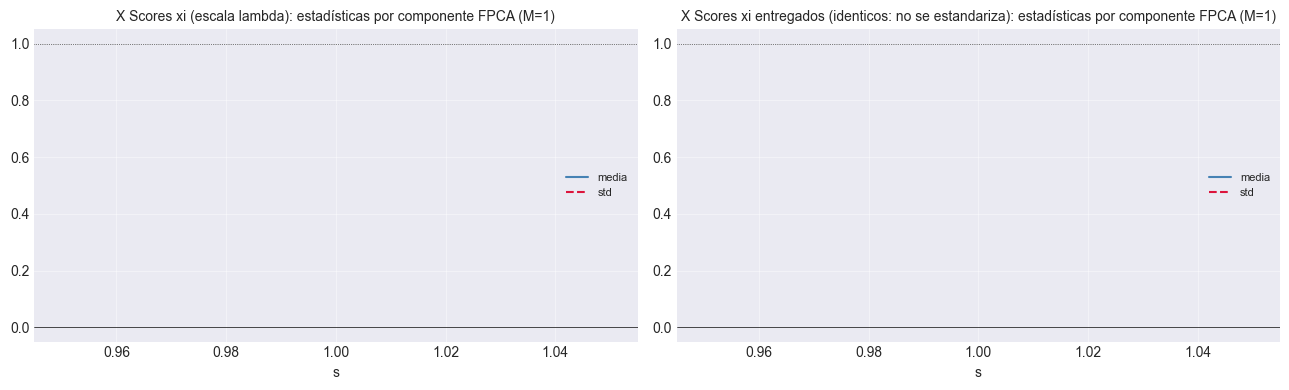

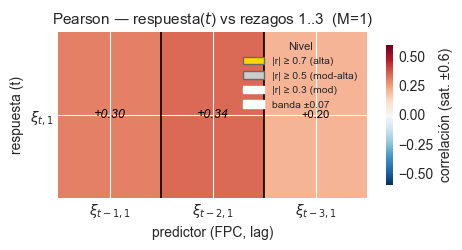

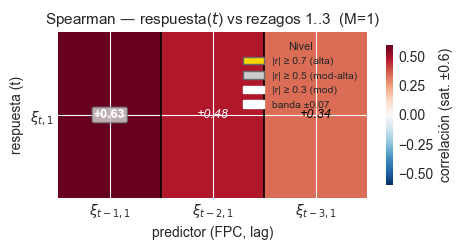

componentes : 1 -> índices [0]
N_LAGS      : 2   ·   p = 2 covariable(s) por componente (rezago_propio)
n_train_eff : 698   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_1_lag2']
[functional] 2 datasets + datasets_manifest.json
  fpc_1: train (698, 3) · test (300, 3)
FPC 1: G* = [-2.893, 1.721]   sd_i|x - Gamma| = [0.6329 0.5993]
  FPC 1: sd_y=0.685  btau=0.2345  taupsij=[4.69 4.68]

N_CHAINS = 2 cadenas por componente -> 2 jobs en MATLAB para este M
R^2 AR(2) propio (train) = [0.158]   ->   razon sugerida max(1, 1/(2(1-R^2))) = [1.]
   k  fpc  sd_gate  sd real  media arg  cv_psi  Etau*lam    var(y)   E[tau]      btau
   0    1     0.80     0.00       0.00    1.00      1.00   0.46909     2.13   0.23455   <- gating DEBIL

peso del prior sobre psi por componente = [22.1] %   (>30 % = psi clavado en mupsij, gating congelado)

   k       covariable       tipo   apij   bpij   E[pi]  P(escape)   espera
   0       fpc_1_lag1   own_lag1  0.500  0.500   0.500   9.30e-02       11
   0      

,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,300.0000,0.6636,0.6636,-0.0004,1.0718,1.0353
persistencia_lag1,300.0000,0.6999,0.6999,-0.1130,1.1214,1.0589


contrato_ok = True   (M=1, K=14, T0=700, n_components=1)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 2   ·   escenario_114_chungEscG_1_r01_m02
M(95 %) según la regla : 6   (K disponible = 14)
M de este punto        : 2   <- DIFIERE de la regla: es un punto de sensibilidad
M = 2   var. explicada = 69.0353%
[train] max|media xi| = 1.73e-16   (~ 0)
[test]  max|media xi| = 0.017
[test]  var xi / lambda = [0.94  0.884]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 2)   (= SCORES: transformacion identidad)
  [train] media = [ 1.734e-16 -5.139e-17]   <- NO se resta
  [train] std   = [0.685 0.55 ]   <- NO se divide
  [test]  media = [ 0.012 -0.017]
  [test]  std   = [0.663 0.517]
  rango que vera MATLAB: [-2.893, 1.721]   <- de ahi sale la grilla G* y con ella la escala del gating

[functional] artefactos FPCA · cond_W = 2.465e+01


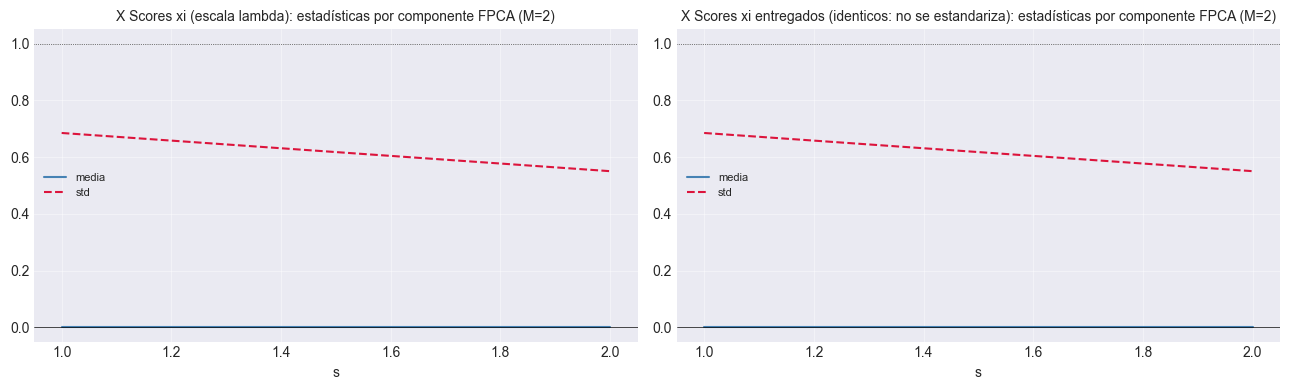

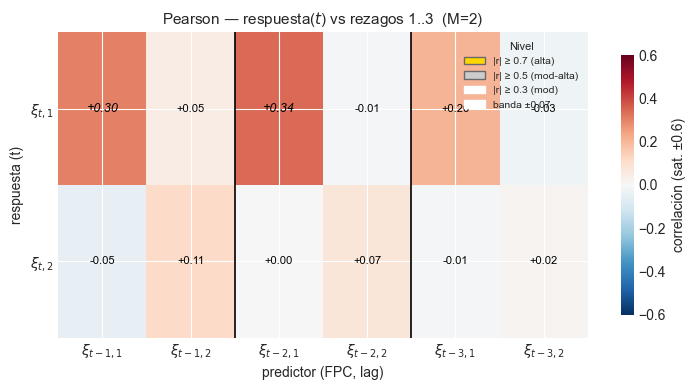

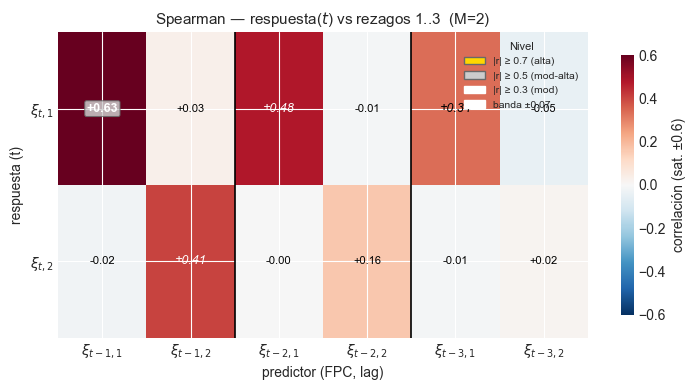

componentes : 2 -> índices [0, 1]
N_LAGS      : 2   ·   p = 2 covariable(s) por componente (rezago_propio)
n_train_eff : 698   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_1_lag2', 'fpc_2_lag2']
[functional] 4 datasets + datasets_manifest.json
  fpc_1: train (698, 3) · test (300, 3)
  fpc_2: train (698, 3) · test (300, 3)
FPC 1: G* = [-2.893, 1.721]   sd_i|x - Gamma| = [0.6329 0.5993]
FPC 2: G* = [-2.169, 1.689]   sd_i|x - Gamma| = [0.4864 0.4792]
  FPC 1: sd_y=0.685  btau=0.2345  taupsij=[4.69 4.68]
  FPC 2: sd_y=0.550  btau=0.1514  taupsij=[3.03 3.03]

N_CHAINS = 2 cadenas por componente -> 4 jobs en MATLAB para este M
R^2 AR(2) propio (train) = [0.158 0.017]   ->   razon sugerida max(1, 1/(2(1-R^2))) = [1. 1.]
   k  fpc  sd_gate  sd real  media arg  cv_psi  Etau*lam    var(y)   E[tau]      btau
   0    1     0.80     0.00       0.00    1.00      1.00   0.46909     2.13   0.23455   <- gating DEBIL
   1    2     0.80     0.00       0.00    1.00      1.00   0.30285 

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,
media_incondicional,300.0000,0.6636,0.5174,0.5905,-0.0007,1.0718,1.0353
persistencia_lag1,300.0000,0.6999,0.6898,0.6948,-0.4462,1.3295,1.1530


contrato_ok = True   (M=2, K=14, T0=700, n_components=2)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 3   ·   escenario_114_chungEscG_1_r01_m03
M(95 %) según la regla : 6   (K disponible = 14)
M de este punto        : 3   <- DIFIERE de la regla: es un punto de sensibilidad
M = 3   var. explicada = 83.8132%
[train] max|media xi| = 1.85e-16   (~ 0)
[test]  max|media xi| = 0.038
[test]  var xi / lambda = [0.94  0.884 0.913]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 3)   (= SCORES: transformacion identidad)
  [train] media = [ 1.734e-16 -5.139e-17 -1.855e-16]   <- NO se resta
  [train] std   = [0.685 0.55  0.407]   <- NO se divide
  [test]  media = [ 0.012 -0.017  0.038]
  [test]  std   = [0.663 0.517 0.388]
  rango que vera MATLAB: [-2.893, 1.721]   <- de ahi sale la grilla G* y con ella la escala del gating

[functional] artefactos FPCA · cond_W = 2.465e+01


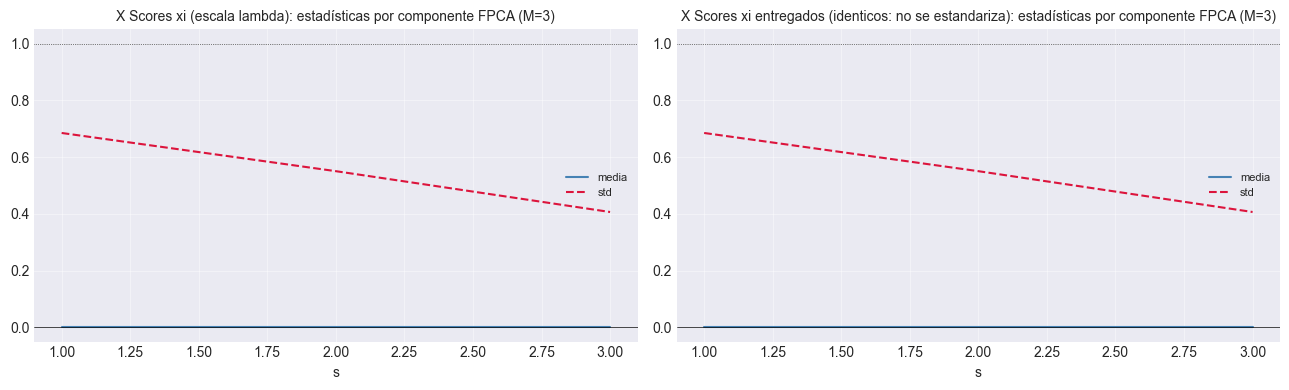

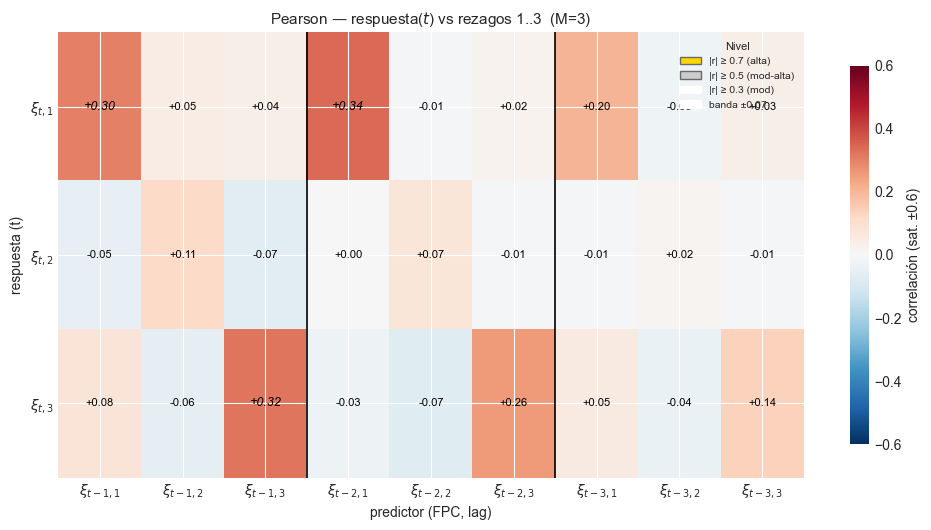

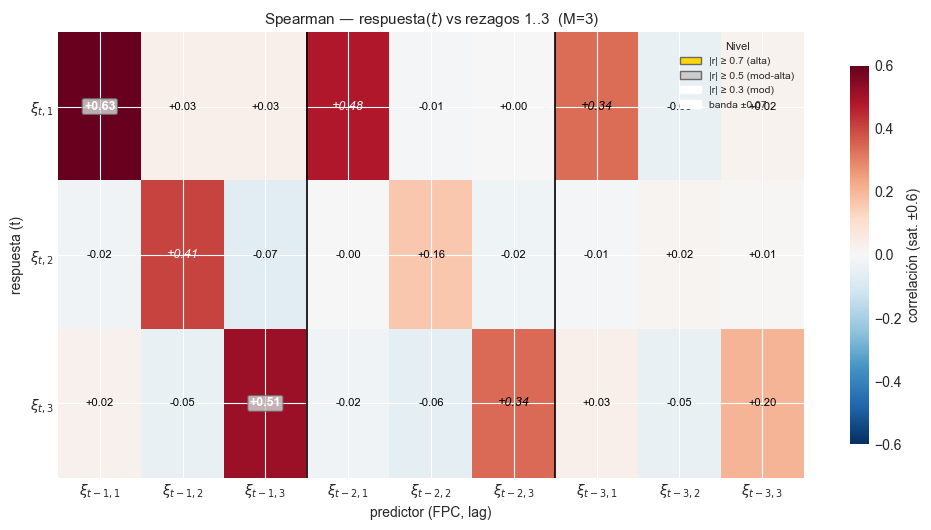

componentes : 3 -> índices [0, 1, 2]
N_LAGS      : 2   ·   p = 2 covariable(s) por componente (rezago_propio)
n_train_eff : 698   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2']
[functional] 6 datasets + datasets_manifest.json
  fpc_1: train (698, 3) · test (300, 3)
  fpc_2: train (698, 3) · test (300, 3)
  fpc_3: train (698, 3) · test (300, 3)
FPC 1: G* = [-2.893, 1.721]   sd_i|x - Gamma| = [0.6329 0.5993]
FPC 2: G* = [-2.169, 1.689]   sd_i|x - Gamma| = [0.4864 0.4792]
FPC 3: G* = [-1.555, 1.082]   sd_i|x - Gamma| = [0.354  0.3468]
  FPC 1: sd_y=0.685  btau=0.2345  taupsij=[4.69 4.68]
  FPC 2: sd_y=0.550  btau=0.1514  taupsij=[3.03 3.03]
  FPC 3: sd_y=0.407  btau=0.0826  taupsij=[1.66 1.66]

N_CHAINS = 2 cadenas por componente -> 6 jobs en MATLAB para este M
R^2 AR(2) propio (train) = [0.158 0.017 0.129]   ->   razon sugerida max(1, 1/(2(1-R^2))) = [1. 1. 1.]
   k  fpc  sd_gate  sd real  media arg  cv_psi  Etau*lam   

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,300.0000,0.6636,0.5174,0.3898,0.5236,-0.0036,1.0718,1.0353
persistencia_lag1,300.0000,0.6999,0.6898,0.4389,0.6095,-0.3907,1.3702,1.1705


contrato_ok = True   (M=3, K=14, T0=700, n_components=3)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 4   ·   escenario_114_chungEscG_1_r01_m04
M(95 %) según la regla : 6   (K disponible = 14)
M de este punto        : 4   <- DIFIERE de la regla: es un punto de sensibilidad
M = 4   var. explicada = 90.8720%
[train] max|media xi| = 1.85e-16   (~ 0)
[test]  max|media xi| = 0.053
[test]  var xi / lambda = [0.94  0.884 0.913 1.257]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 4)   (= SCORES: transformacion identidad)
  [train] media = [ 1.734e-16 -5.139e-17 -1.855e-16 -1.350e-16]   <- NO se resta
  [train] std   = [0.685 0.55  0.407 0.281]   <- NO se divide
  [test]  media = [ 0.012 -0.017  0.038  0.053]
  [test]  std   = [0.663 0.517 0.388 0.315]
  rango que vera MATLAB: [-2.893, 1.721]   <- de ahi sale la grilla G* y con ella la escala del gating

[functional] artefactos FPCA · cond_W = 2.465e+01


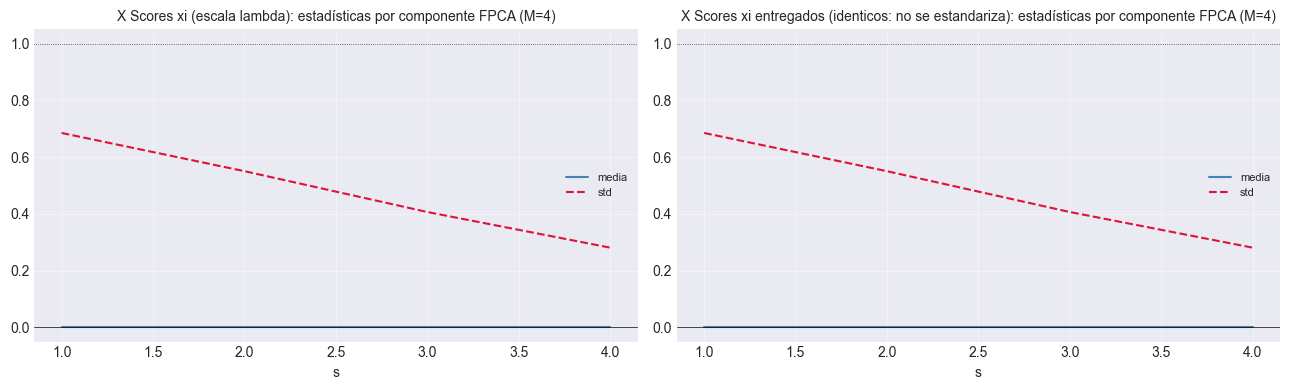

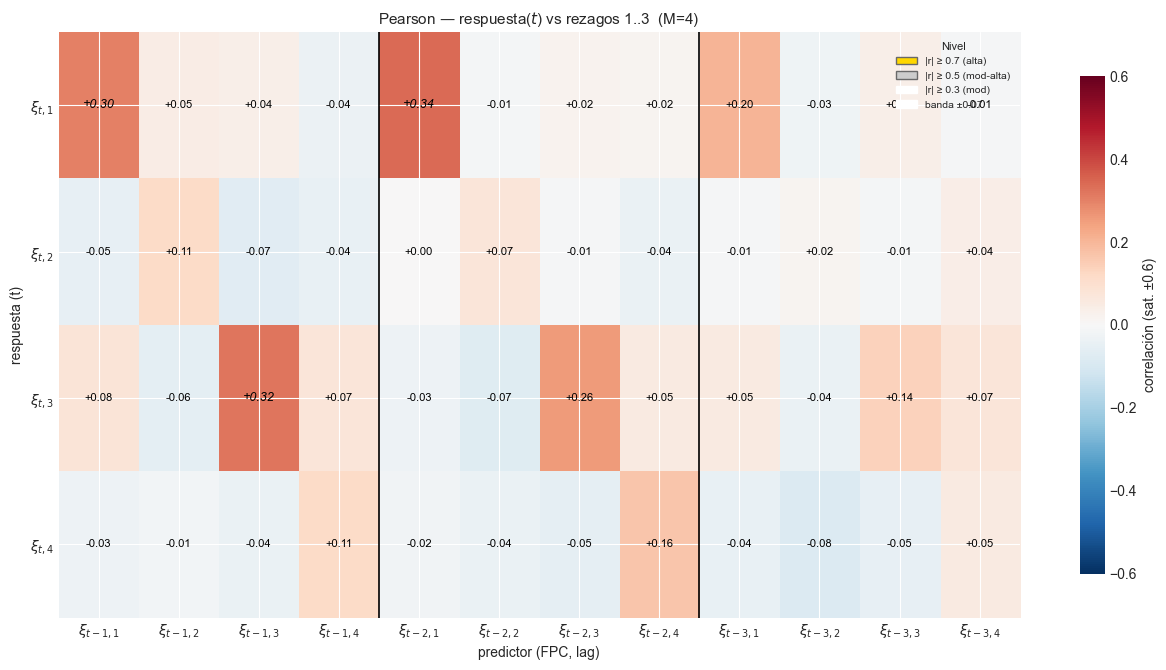

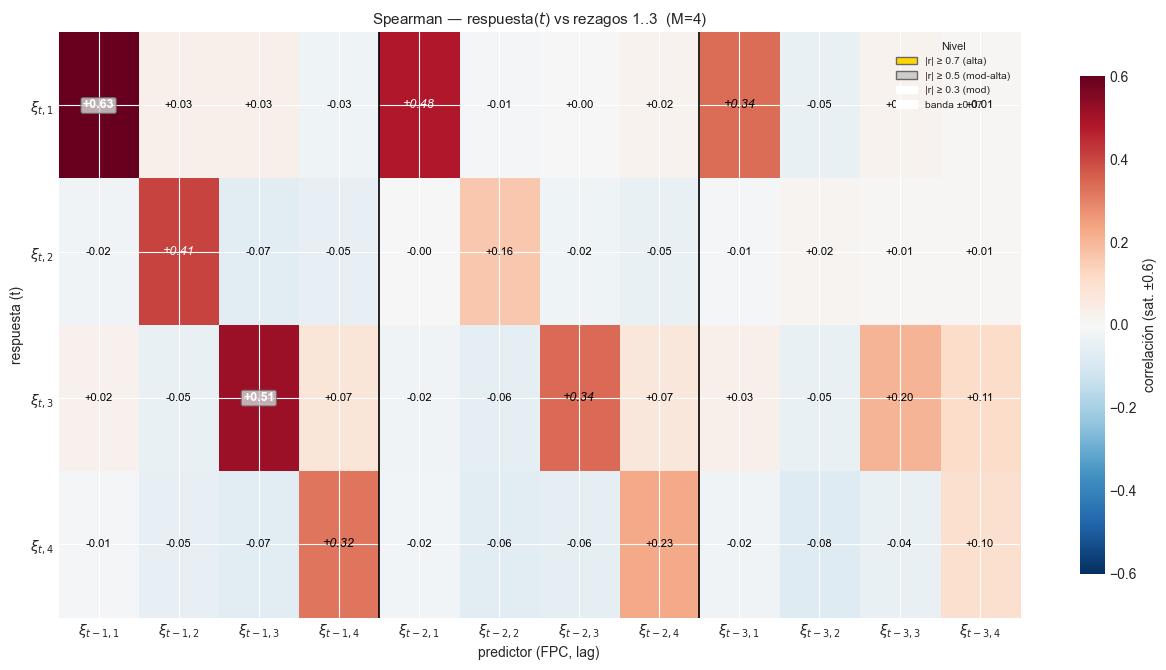

componentes : 4 -> índices [0, 1, 2, 3]
N_LAGS      : 2   ·   p = 2 covariable(s) por componente (rezago_propio)
n_train_eff : 698   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2']
[functional] 8 datasets + datasets_manifest.json
  fpc_1: train (698, 3) · test (300, 3)
  fpc_2: train (698, 3) · test (300, 3)
  fpc_3: train (698, 3) · test (300, 3)
  fpc_4: train (698, 3) · test (300, 3)
FPC 1: G* = [-2.893, 1.721]   sd_i|x - Gamma| = [0.6329 0.5993]
FPC 2: G* = [-2.169, 1.689]   sd_i|x - Gamma| = [0.4864 0.4792]
FPC 3: G* = [-1.555, 1.082]   sd_i|x - Gamma| = [0.354  0.3468]
FPC 4: G* = [-0.932, 0.640]   sd_i|x - Gamma| = [0.2376 0.2466]
  FPC 1: sd_y=0.685  btau=0.2345  taupsij=[4.69 4.68]
  FPC 2: sd_y=0.550  btau=0.1514  taupsij=[3.03 3.03]
  FPC 3: sd_y=0.407  btau=0.0826  taupsij=[1.66 1.66]
  FPC 4: sd_y=0.281  btau=0.0395  taupsij=[0.79 0.79]

N_CHAINS = 2 cadenas por componente -> 8 

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,
media_incondicional,300.0000,0.6636,0.5174,0.3898,0.3190,0.4724,-0.0098,1.0718,1.0353
persistencia_lag1,300.0000,0.6999,0.6898,0.4389,0.4320,0.5652,-0.5144,1.4550,1.2062


contrato_ok = True   (M=4, K=14, T0=700, n_components=4)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 5   ·   escenario_114_chungEscG_1_r01_m05
M(95 %) según la regla : 6   (K disponible = 14)
M de este punto        : 5   <- DIFIERE de la regla: es un punto de sensibilidad
M = 5   var. explicada = 94.7999%
[train] max|media xi| = 2.15e-16   (~ 0)
[test]  max|media xi| = 0.053
[test]  var xi / lambda = [0.94  0.884 0.913 1.257 1.051]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 5)   (= SCORES: transformacion identidad)
  [train] media = [ 1.734e-16 -5.139e-17 -1.855e-16 -1.350e-16 -2.152e-16]   <- NO se resta
  [train] std   = [0.685 0.55  0.407 0.281 0.21 ]   <- NO se divide
  [test]  media = [ 0.012 -0.017  0.038  0.053  0.006]
  [test]  std   = [0.663 0.517 0.388 0.315 0.215]
  rango que vera MATLAB: [-2.893, 1.721]   <- de ahi sale la grilla G* y con ella la escala del gating

[functional] artefactos FPCA

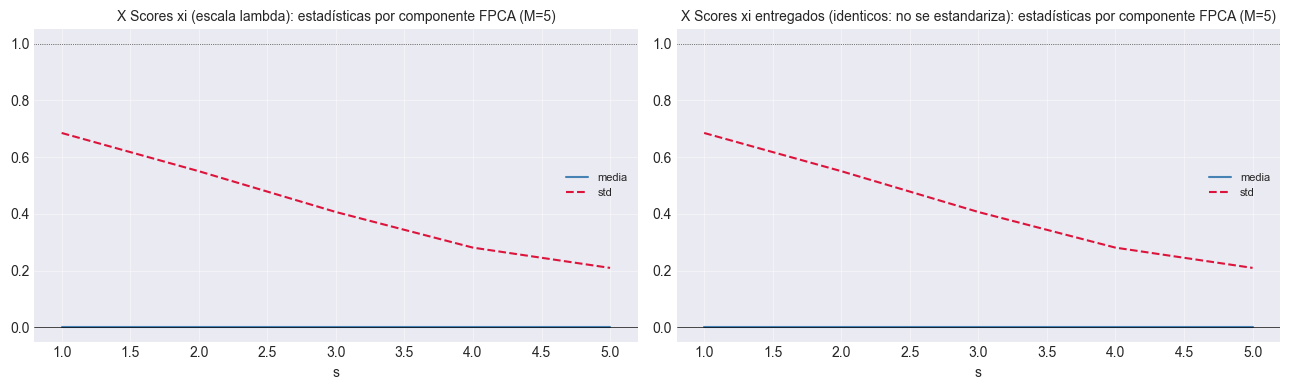

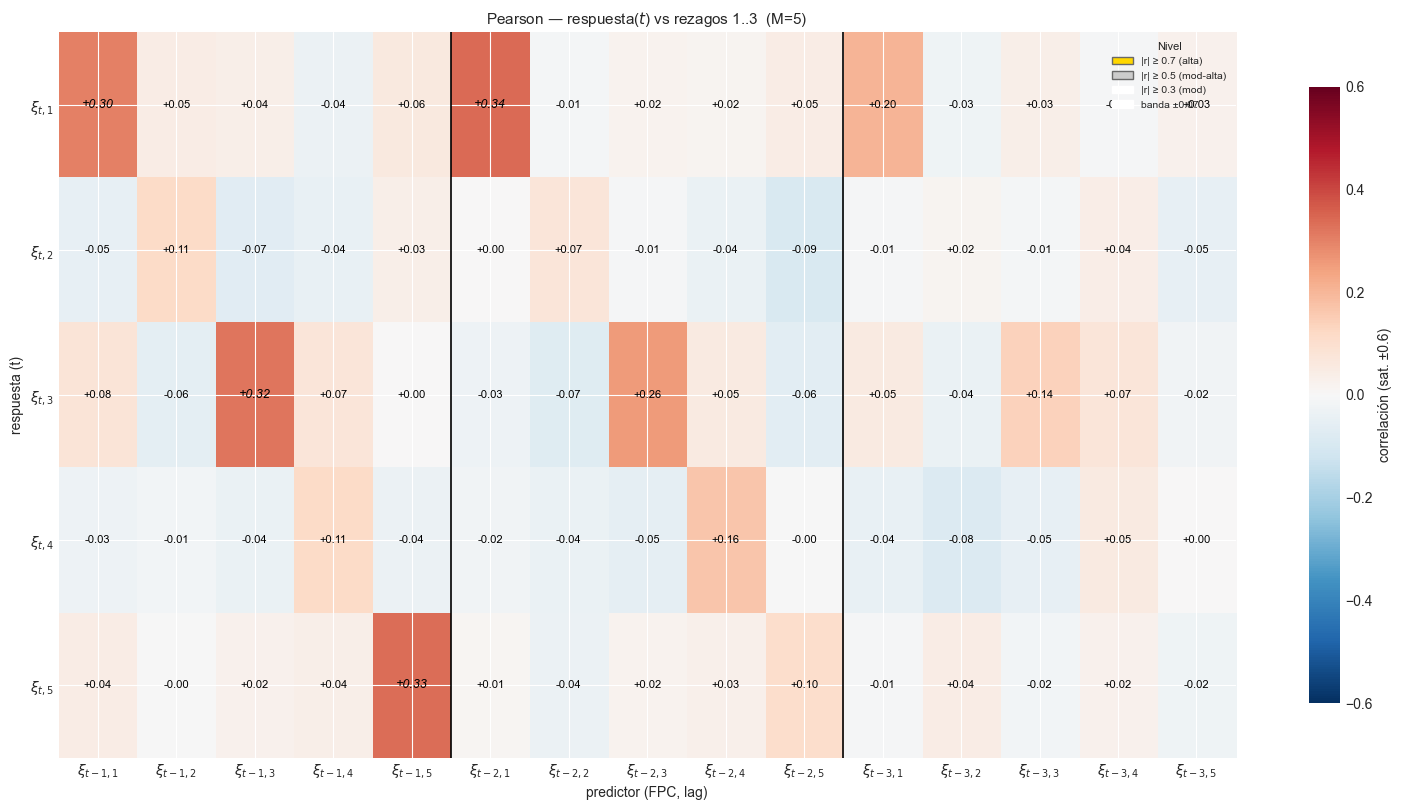

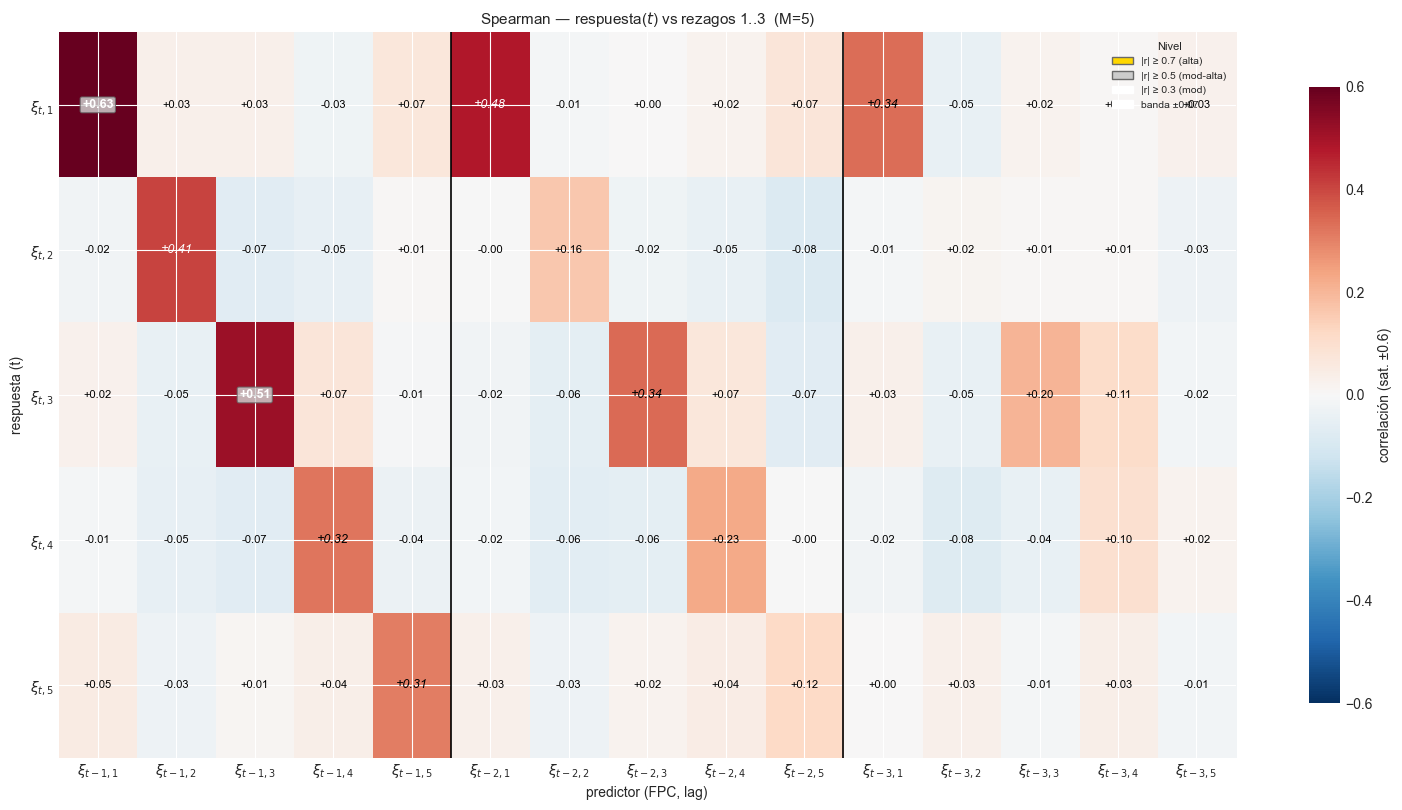

componentes : 5 -> índices [0, 1, 2, 3, 4]
N_LAGS      : 2   ·   p = 2 covariable(s) por componente (rezago_propio)
n_train_eff : 698   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2']
[functional] 10 datasets + datasets_manifest.json
  fpc_1: train (698, 3) · test (300, 3)
  fpc_2: train (698, 3) · test (300, 3)
  fpc_3: train (698, 3) · test (300, 3)
  fpc_4: train (698, 3) · test (300, 3)
  fpc_5: train (698, 3) · test (300, 3)
FPC 1: G* = [-2.893, 1.721]   sd_i|x - Gamma| = [0.6329 0.5993]
FPC 2: G* = [-2.169, 1.689]   sd_i|x - Gamma| = [0.4864 0.4792]
FPC 3: G* = [-1.555, 1.082]   sd_i|x - Gamma| = [0.354  0.3468]
FPC 4: G* = [-0.932, 0.640]   sd_i|x - Gamma| = [0.2376 0.2466]
FPC 5: G* = [-0.655, 0.663]   sd_i|x - Gamma| = [0.1716 0.176 ]
  FPC 1: sd_y=0.685  btau=0.2345  taupsij=[4.69 4.68]
  FPC 2: sd_y=0.550  btau=0.1514  taupsij=[3.03 3.03]
  FPC 3: sd_y=

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,
media_incondicional,300.0000,0.6636,0.5174,0.3898,0.3190,0.2147,0.4209,-0.0080,1.0718,1.0353
persistencia_lag1,300.0000,0.6999,0.6898,0.4389,0.4320,0.2582,0.5038,-0.5010,1.4756,1.2147


contrato_ok = True   (M=5, K=14, T0=700, n_components=5)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 6   ·   escenario_114_chungEscG_1_r01_m06
M(95 %) según la regla : 6   (K disponible = 14)
M de este punto        : 6   (coincide con la regla)
M = 6   var. explicada = 97.0205%
[train] max|media xi| = 2.15e-16   (~ 0)
[test]  max|media xi| = 0.053
[test]  var xi / lambda = [0.94  0.884 0.913 1.257 1.051 1.053]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 6)   (= SCORES: transformacion identidad)
  [train] media = [ 1.734e-16 -5.139e-17 -1.855e-16 -1.350e-16 -2.152e-16  1.557e-16]   <- NO se resta
  [train] std   = [0.685 0.55  0.407 0.281 0.21  0.158]   <- NO se divide
  [test]  media = [ 0.012 -0.017  0.038  0.053  0.006  0.028]
  [test]  std   = [0.663 0.517 0.388 0.315 0.215 0.162]
  rango que vera MATLAB: [-2.893, 1.721]   <- de ahi sale la grilla G* y con ella la escala del gating

[functional] artefac

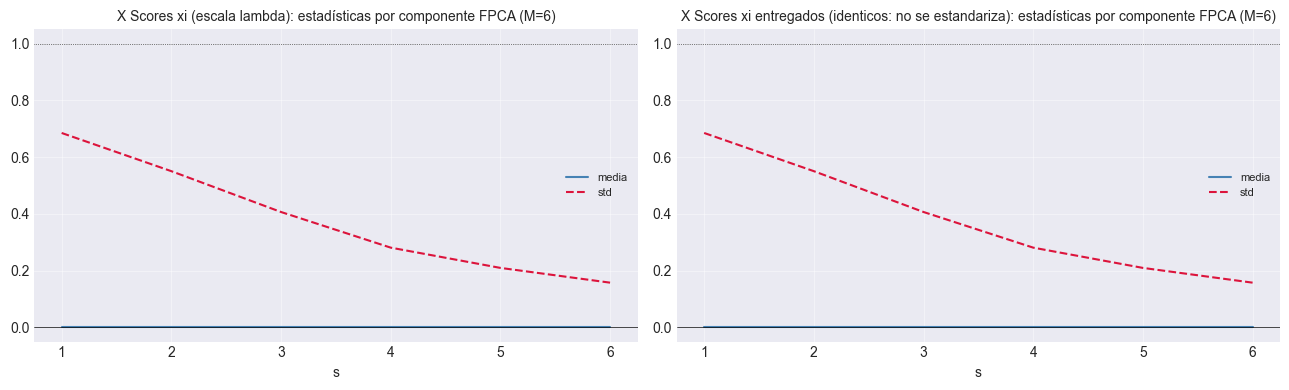

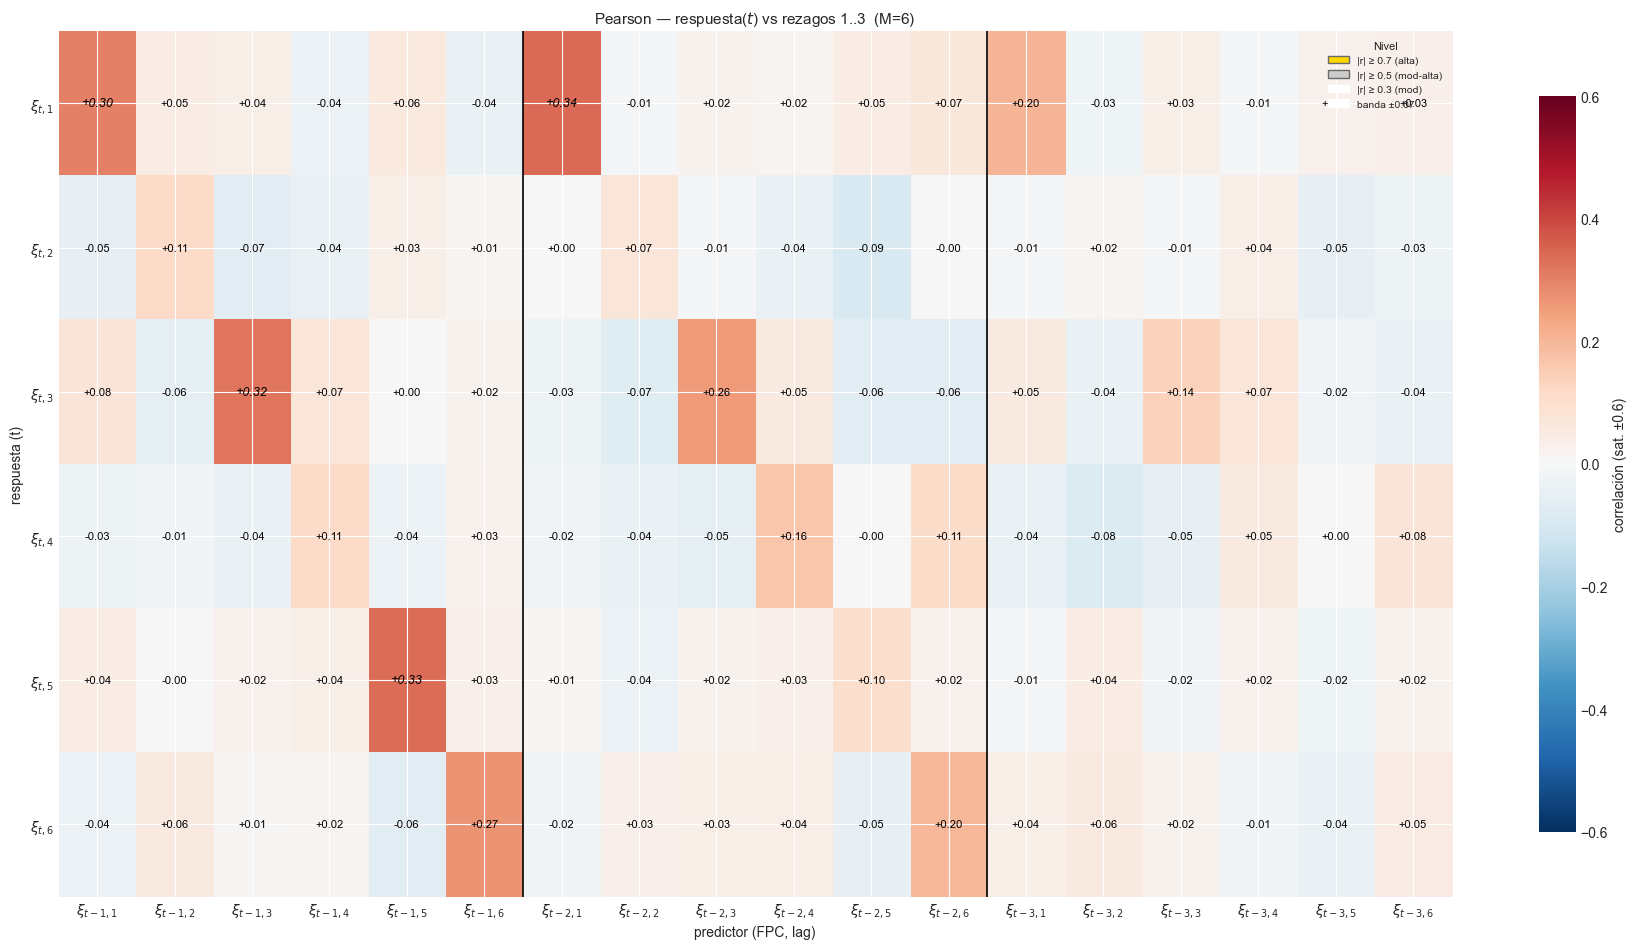

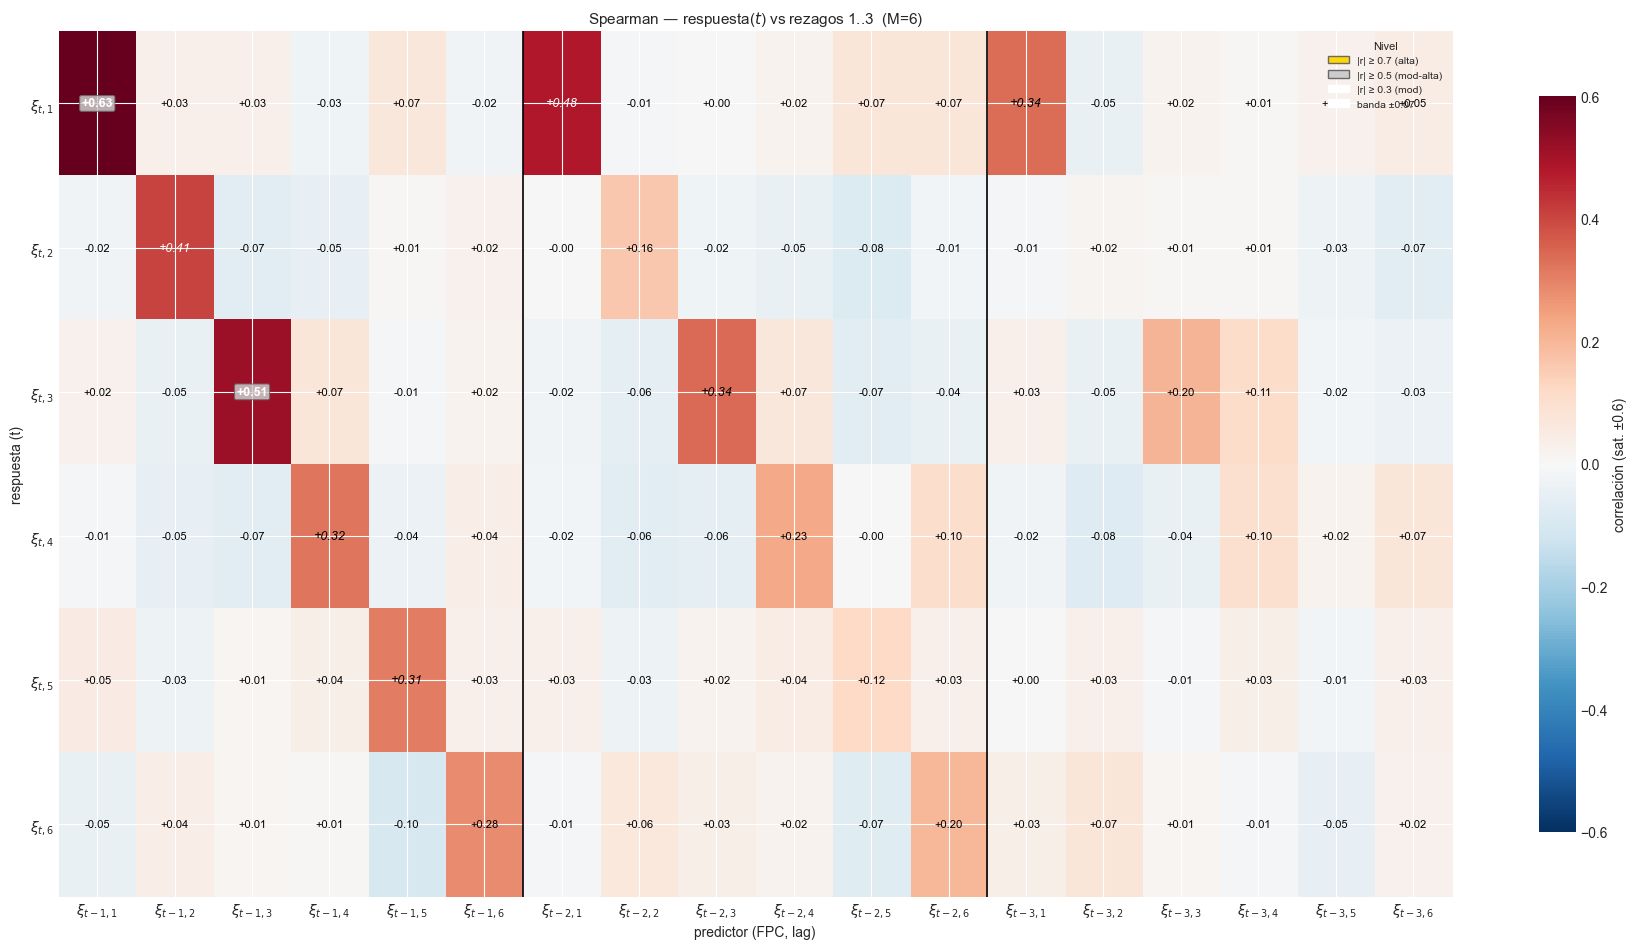

componentes : 6 -> índices [0, 1, 2, 3, 4, 5]
N_LAGS      : 2   ·   p = 2 covariable(s) por componente (rezago_propio)
n_train_eff : 698   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2', 'fpc_6_lag2']
[functional] 12 datasets + datasets_manifest.json
  fpc_1: train (698, 3) · test (300, 3)
  fpc_2: train (698, 3) · test (300, 3)
  fpc_3: train (698, 3) · test (300, 3)
  fpc_4: train (698, 3) · test (300, 3)
  fpc_5: train (698, 3) · test (300, 3)
  fpc_6: train (698, 3) · test (300, 3)
FPC 1: G* = [-2.893, 1.721]   sd_i|x - Gamma| = [0.6329 0.5993]
FPC 2: G* = [-2.169, 1.689]   sd_i|x - Gamma| = [0.4864 0.4792]
FPC 3: G* = [-1.555, 1.082]   sd_i|x - Gamma| = [0.354  0.3468]
FPC 4: G* = [-0.932, 0.640]   sd_i|x - Gamma| = [0.2376 0.2466]
FPC 5: G* = [-0.655, 0.663]   sd_i|x - Gamma| = [0.1716 0.176 ]
FPC 6: G* = [-0.613, 0.395]   sd_i|x - Gamma| = [0.

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,
media_incondicional,300.0000,0.6636,0.5174,0.3898,0.3190,0.2147,0.1640,0.3781,-0.0117,1.0718,1.0353
persistencia_lag1,300.0000,0.6999,0.6898,0.4389,0.4320,0.2582,0.1853,0.4507,-0.4700,1.4830,1.2178


contrato_ok = True   (M=6, K=14, T0=700, n_components=6)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True


In [20]:
# -- [CONFIG] Comunes a TODOS los puntos del barrido -------------------------
# Rezago propio: xi_(k,t) se predice con xi_(k,t-l), l = 1..N_LAGS. N_LAGS es
# el L del anexo: no es perilla.
N_LAGS = 2
assert N_LAGS == SIM_CFG.n_rezagos == 2, "N_LAGS = 2: la dinámica usa 1 rezago y el 2 prueba la selección."
# Misma config que 104-106.
MCMC_CONFIG = {"nsim": 3000, "burn": 500, "N": VAR_CFG["N"], "M": 50}   # ojo: ese M es G*
N_CHAINS    = 2

_PAPER     = VAR_CFG["hiperparametros"] == "chung_dunson_4.2"
_CHUNG_ESC = VAR_CFG["hiperparametros"] == "chung_escala_cruda"

# "paper": Chung y Dunson (2009) §4.2, sobre los scores CRUDOS (sin estandarizar).
# "calib": la 107 (ag=2, atau/btau por componente desde HP_ESCALERA).
HP_GLOBAL = ({"atau": 0.5, "btau": 0.5, "ag": 0.5, "bg": 0.5,
              "mumu": 0.0, "taumu": 1.0, "pwj": 0.5} if (_PAPER or _CHUNG_ESC) else
             {"atau": 2.0, "btau": 0.5, "ag": 2.0, "bg": 0.5,
              "mumu": 0.0, "taumu": 1.0, "pwj": 0.5})
HP_PAPER_COV = {"apij": 0.5, "bpij": 0.5, "mupsij": 0.0, "taupsij": 100.0}

# "calib": apij=1, bpij=5 (Case1_01.m del autor, NO el paper). "paper": 0.5/0.5.
_AB = (0.5, 0.5) if _PAPER else (1.0, 5.0)
HP_BY_TYPE = {f"own_lag{l}": {"apij": _AB[0], "bpij": _AB[1]} for l in range(1, N_LAGS + 1)}

# "chungEsc": Chung §4.2 llevado a la escala cruda. Si x = sd*z, el prior del
# paper sobre z equivale a taupsij = 100*sd_x^2 y btau = 0.5*sd_y^2 (se aplican
# en procesar_punto). Inclusion: Chung en el lag 1, bpij = 5 en el lag 2.
HP_CHUNG_ESC = {"taupsij_z": float(VAR_CFG.get("taupsij_z", 100.0)), "btau_z": 0.5,
                "ab_por_lag": {1: (0.5, 0.5), 2: (0.5, 5.0)},
                "ab_cruzado": (0.5, 5.0)}
if _CHUNG_ESC:
    HP_BY_TYPE = {f"own_lag{l}": {"apij": HP_CHUNG_ESC["ab_por_lag"][l][0],
                                  "bpij": HP_CHUNG_ESC["ab_por_lag"][l][1]}
                  for l in range(1, N_LAGS + 1)}
# Cruzados (variante chungEscX): mismo prior de inclusion para todo rezago ajeno.
_AB_X = HP_CHUNG_ESC["ab_cruzado"] if _CHUNG_ESC else _AB
HP_BY_TYPE.update({f"cross_lag{l}": {"apij": _AB_X[0], "bpij": _AB_X[1]}
                   for l in range(1, N_LAGS + 1)})
_N_ATOMOS = MCMC_CONFIG["N"]
print(f"VARIANTE {VARIANTE!r}: HP_GLOBAL={HP_GLOBAL}")
for _t, _v in HP_BY_TYPE.items():
    print(f"  {_t}: apij={_v['apij']}, bpij={_v['bpij']}  E[pi]={_v['apij'] / (_v['apij'] + _v['bpij']):.3f}")
print(f"N={_N_ATOMOS}"
      + ("  ·  mupsij=0, taupsij=100 (paper)" if _PAPER else "")
      + (f"  ·  mupsij=0, taupsij={HP_CHUNG_ESC['taupsij_z']:g}*sd_x^2, btau=0.5*sd_y^2 (Chung en escala cruda)"
         if _CHUNG_ESC else ""))

# Gating por dispersion (sd_gate_objetivo, cv_psi) como 101-106.
# razon_Etau_lambda = max(1, 1/(2(1-R^2))), R^2 del AR(N_LAGS) propio en train
# medido sobre esta realizacion: (0.62, 0.29, 0.10, 0.06, 0.11, 0.07) para k = 1..6.
# El prior cree min(lambda_k, 2x el residuo AR). atau > 1: sd predictiva finita.
_PELDANO = {"sd_gate_objetivo": 0.8, "cv_psi": 1.0, "atau": 2.0, "razon_Etau_lambda": 1.0}
HP_ESCALERA = {
    0: {**_PELDANO, "atau": 2.5, "razon_Etau_lambda": 1.3},
    **{k: dict(_PELDANO) for k in range(1, 6)},
}

assert all(k in HP_ESCALERA for k in range(max(M_FPCA_LIST))), (
    f"HP_ESCALERA necesita peldanos 0..{max(M_FPCA_LIST) - 1} para "
    f"M_FPCA_LIST={list(M_FPCA_LIST)}.")

_CLAVE_ETAU = clave_etau({k: HP_ESCALERA[k] for k in range(max(M_FPCA_LIST))})

print("\nescalera por componente (btau se despeja en procesar_punto)"
      + ("  ·  NO SE USA en esta variante" if (_PAPER or _CHUNG_ESC) else "") + ":")
print(f"  {'k':>2} {'sd_gate':>8} {'cv_psi':>7} {'atau':>6} {_CLAVE_ETAU:>18}")
for _k in range(max(M_FPCA_LIST)):
    _e = HP_ESCALERA[_k]
    print(f"  {_k:>2} {_e['sd_gate_objetivo']:>8.2f} {_e['cv_psi']:>7.2f} "
          f"{_e['atau']:>6.2f} {_e[_CLAVE_ETAU]:>18.2f}")

print(f"\nN_LAGS      : {N_LAGS}   (p = M x {N_LAGS})")
print(f"MCMC_CONFIG : {MCMC_CONFIG}   (su 'M' es la grilla G* del stick-breaking)")
print(f"N_CHAINS    : {N_CHAINS}")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) x {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")

RESUMEN = [procesar_punto(M) for M in M_FPCA_LIST]


## 5. Resumen del barrido

In [21]:
resumen_df = pd.DataFrame(RESUMEN).set_index("M")
display(resumen_df[["experiment_id", "var_acum", "K", "coincide_regla_95",
                    "n_components", "p_covariables", "contrato_ok"]]
        .style.format({"var_acum": "{:.4%}"})
        .set_caption(f"Barrido en M · {EXPERIMENT_BASE} · "
                     f"K disponible = {resumen_df['K'].iloc[0]}"))

_fallidos = [r for r in RESUMEN if not r["contrato_ok"]]
for r in _fallidos:
    print(f"\n[FALLA] M={r['M']} ({r['experiment_id']}):")
    for p in r["problemas"]:
        print(f"  - {p}")
assert not _fallidos, (
    f"El contrato falla en M = {[r['M'] for r in _fallidos]}. No lanzar MATLAB: "
    f"psbp_fd_iteracion.m leería artefactos inconsistentes.")

print(f"\n{'='*70}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      + (f"con M_FPCA_LIST = {list(M_FPCA_LIST)}   (cruzados: se entrena CADA M)\n"
         if CRUZADOS else
         f"con M_FPCA_LIST = [{M_ENTRENO}]   (solo se entrena M={M_ENTRENO}: "
         f"los M menores reutilizan sus trazas)\n")
      + f"Antes, correr este notebook con cada VARIANTE de {list(VARIANTES)}.\n{'='*70}")

,experiment_id,var_acum,K,coincide_regla_95,n_components,p_covariables,contrato_ok
M,,,,,,,
1,escenario_114_chungEscG_1_r01_m01,41.9511%,14,False,1,2,True
2,escenario_114_chungEscG_1_r01_m02,69.0353%,14,False,2,2,True
3,escenario_114_chungEscG_1_r01_m03,83.8132%,14,False,3,2,True
4,escenario_114_chungEscG_1_r01_m04,90.8720%,14,False,4,2,True
5,escenario_114_chungEscG_1_r01_m05,94.7999%,14,False,5,2,True
6,escenario_114_chungEscG_1_r01_m06,97.0205%,14,True,6,2,True



Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
con M_FPCA_LIST = [6]   (solo se entrena M=6: los M menores reutilizan sus trazas)
Antes, correr este notebook con cada VARIANTE de ['chungEscG', 'chungEsc'].
